# Notebook 04 — RQ3: How Do Signatures Vary with Market Conditions?

**Research Question 3:** *How do these signatures vary with observable market conditions, especially liquidity proxies (spread/depth), activity proxies (trade-rate), and time-to-resolution?*

This notebook analyses **16 resolved US political markets** from Polymarket to determine how the heavy-tail, volatility-clustering, and reversal signatures identified in Stage 1 co-vary with:
1. **Activity proxies** — hourly trade rate (`trade_rate_1h`) and 24-hour rolling trade rate (`trade_rate_24h`)
2. **Time-to-resolution** — days remaining until market resolution
3. **Cross-market variation** — whether high-volume vs low-volume, or different market types (presidential, nomination, VP, state-level, policy), exhibit systematically different signature–condition relationships

Since all markets are resolved, live order-book liquidity data is unavailable; we therefore rely on trade-derived activity proxies as our best available liquidity indicator.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', font_scale=1.1)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import POLITICS_MARKETS, DATA_PROCESSED

print(f'Project root: {PROJECT_ROOT}')
print(f'Markets configured: {len(POLITICS_MARKETS)}')

Project root: /Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics
Markets configured: 18


## 0. Data Loading & Overview

In [2]:
df_all = pd.read_parquet(DATA_PROCESSED / 'features_politics.parquet')
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], utc=True)

# Short display labels
LABEL_MAP = {
    'will-donald-trump-win-the-2024-us-presidential-election': 'Trump Pres.',
    'will-kamala-harris-win-the-2024-us-presidential-election': 'Harris Pres.',
    'will-kamala-harris-win-the-popular-vote-in-the-2024-presidential-election': 'Harris Pop. Vote',
    'will-donald-trump-win-the-popular-vote-in-the-2024-presidential-election': 'Trump Pop. Vote',
    'will-joe-biden-win-the-2024-us-presidential-election': 'Biden Pres.',
    'will-nikki-haley-win-the-2024-us-presidential-election': 'Haley Pres.',
    'will-robert-f-kennedy-jr-win-the-2024-us-presidential-election': 'RFK Jr. Pres.',
    'will-ron-desantis-win-the-2024-us-presidential-election': 'DeSantis Pres.',
    'will-joe-biden-win-the-2024-democratic-presidential-nomination': 'Biden Nom.',
    'will-kamala-harris-win-the-2024-democratic-presidential-nomination': 'Harris Nom.',
    'will-donald-j-trump-win-the-2024-republican-presidential-nomination': 'Trump GOP Nom.',
    'will-a-republican-win-texas-in-the-2024-us-presidential-election': 'GOP Texas',
    'will-maine-be-the-tipping-point-state': 'Maine Tipping Pt.',
    'us-government-shutdown-by-october-1': 'Gov. Shutdown',
    'joe-biden-impeached-before-2024-election': 'Biden Impeach.',
    'will-nikki-haley-win-the-2024-republican-iowa-caucus': 'Haley Iowa',
}
df_all['label'] = df_all['market_slug'].map(LABEL_MAP).fillna(df_all['market_slug'])

# Market type from config
TYPE_MAP = {m['slug']: m.get('market_type', '') for m in POLITICS_MARKETS}
if 'market_type' not in df_all.columns or df_all['market_type'].isna().all():
    df_all['market_type'] = df_all['market_slug'].map(TYPE_MAP)

print(f'Total observations: {len(df_all):,}')
print(f'Markets: {df_all["market_slug"].nunique()}')
print(f'Columns: {list(df_all.columns)}')

Total observations: 89,063
Markets: 16
Columns: ['timestamp', 'open', 'high', 'low', 'price', 'n_obs', 'market_slug', 'category', 'logit_price', 'logit_return', 'abs_logit_return', 'time_to_resolution', 'trade_rate_1h', 'volume_rate_1h', 'trade_rate_24h', 'volume_rate_24h', 'spread', 'midpoint', 'depth_1c_bid', 'depth_1c_ask', 'depth_5c_bid', 'depth_5c_ask', 'role', 'triad_id', 'market_type', 'label']


In [3]:
# Market overview table
overview = df_all.groupby(['label', 'market_type']).agg(
    n_obs=('logit_return', 'count'),
    price_min=('price', 'min'),
    price_max=('price', 'max'),
    price_range=('price', lambda x: x.max() - x.min()),
    mean_abs_lr=('abs_logit_return', 'mean'),
    std_lr=('logit_return', 'std'),
    kurtosis=('logit_return', lambda x: float(sp_stats.kurtosis(x.dropna()))),
    mean_trade_rate=('trade_rate_1h', 'mean'),
    ttr_min=('time_to_resolution', 'min'),
    ttr_max=('time_to_resolution', 'max'),
).sort_values('n_obs', ascending=False)

overview.style.format({
    'price_min': '{:.3f}', 'price_max': '{:.3f}', 'price_range': '{:.3f}',
    'mean_abs_lr': '{:.4f}', 'std_lr': '{:.4f}', 'kurtosis': '{:.1f}',
    'mean_trade_rate': '{:.1f}', 'ttr_min': '{:.1f}', 'ttr_max': '{:.1f}',
})

,,n_obs,price_min,price_max,price_range,mean_abs_lr,std_lr,kurtosis,mean_trade_rate,ttr_min,ttr_max
label,market_type,,,,,,,,,,
Biden Impeach.,policy,7367,0.002,0.500,0.498,0.0057,0.0454,377.2,160.7,0.0,307.0
Biden Pres.,presidential,7332,0.001,0.500,0.499,0.0060,0.0523,1661.8,2.9,0.0,305.5
Trump Pres.,presidential,7332,0.395,0.715,0.320,0.0043,0.0151,121.3,276.0,0.0,305.5
DeSantis Pres.,presidential,7330,0.001,0.045,0.044,0.0077,0.0548,238.3,0.1,0.0,305.5
Haley Pres.,presidential,7320,0.001,0.500,0.499,0.0128,0.0650,153.5,13.4,0.0,305.0
RFK Jr. Pres.,presidential,7308,0.001,0.500,0.499,0.0134,0.0627,920.8,7.7,0.0,304.5
Harris Pres.,presidential,7306,0.006,0.540,0.534,0.0107,0.0375,168.8,265.0,0.0,304.5
Trump Pop. Vote,popular_vote,7212,0.190,0.585,0.395,0.0051,0.0208,714.0,77.0,0.0,300.5
Harris Pop. Vote,popular_vote,7211,0.007,0.797,0.790,0.0094,0.0668,1459.6,17.0,0.0,300.5


In [4]:
# Per-market feature DataFrames (convenience dict)
market_dfs = {slug: grp.copy() for slug, grp in df_all.groupby('market_slug')}
print(f'Loaded {len(market_dfs)} market DataFrames')

Loaded 16 market DataFrames


## 1. Price Paths & Activity Overview

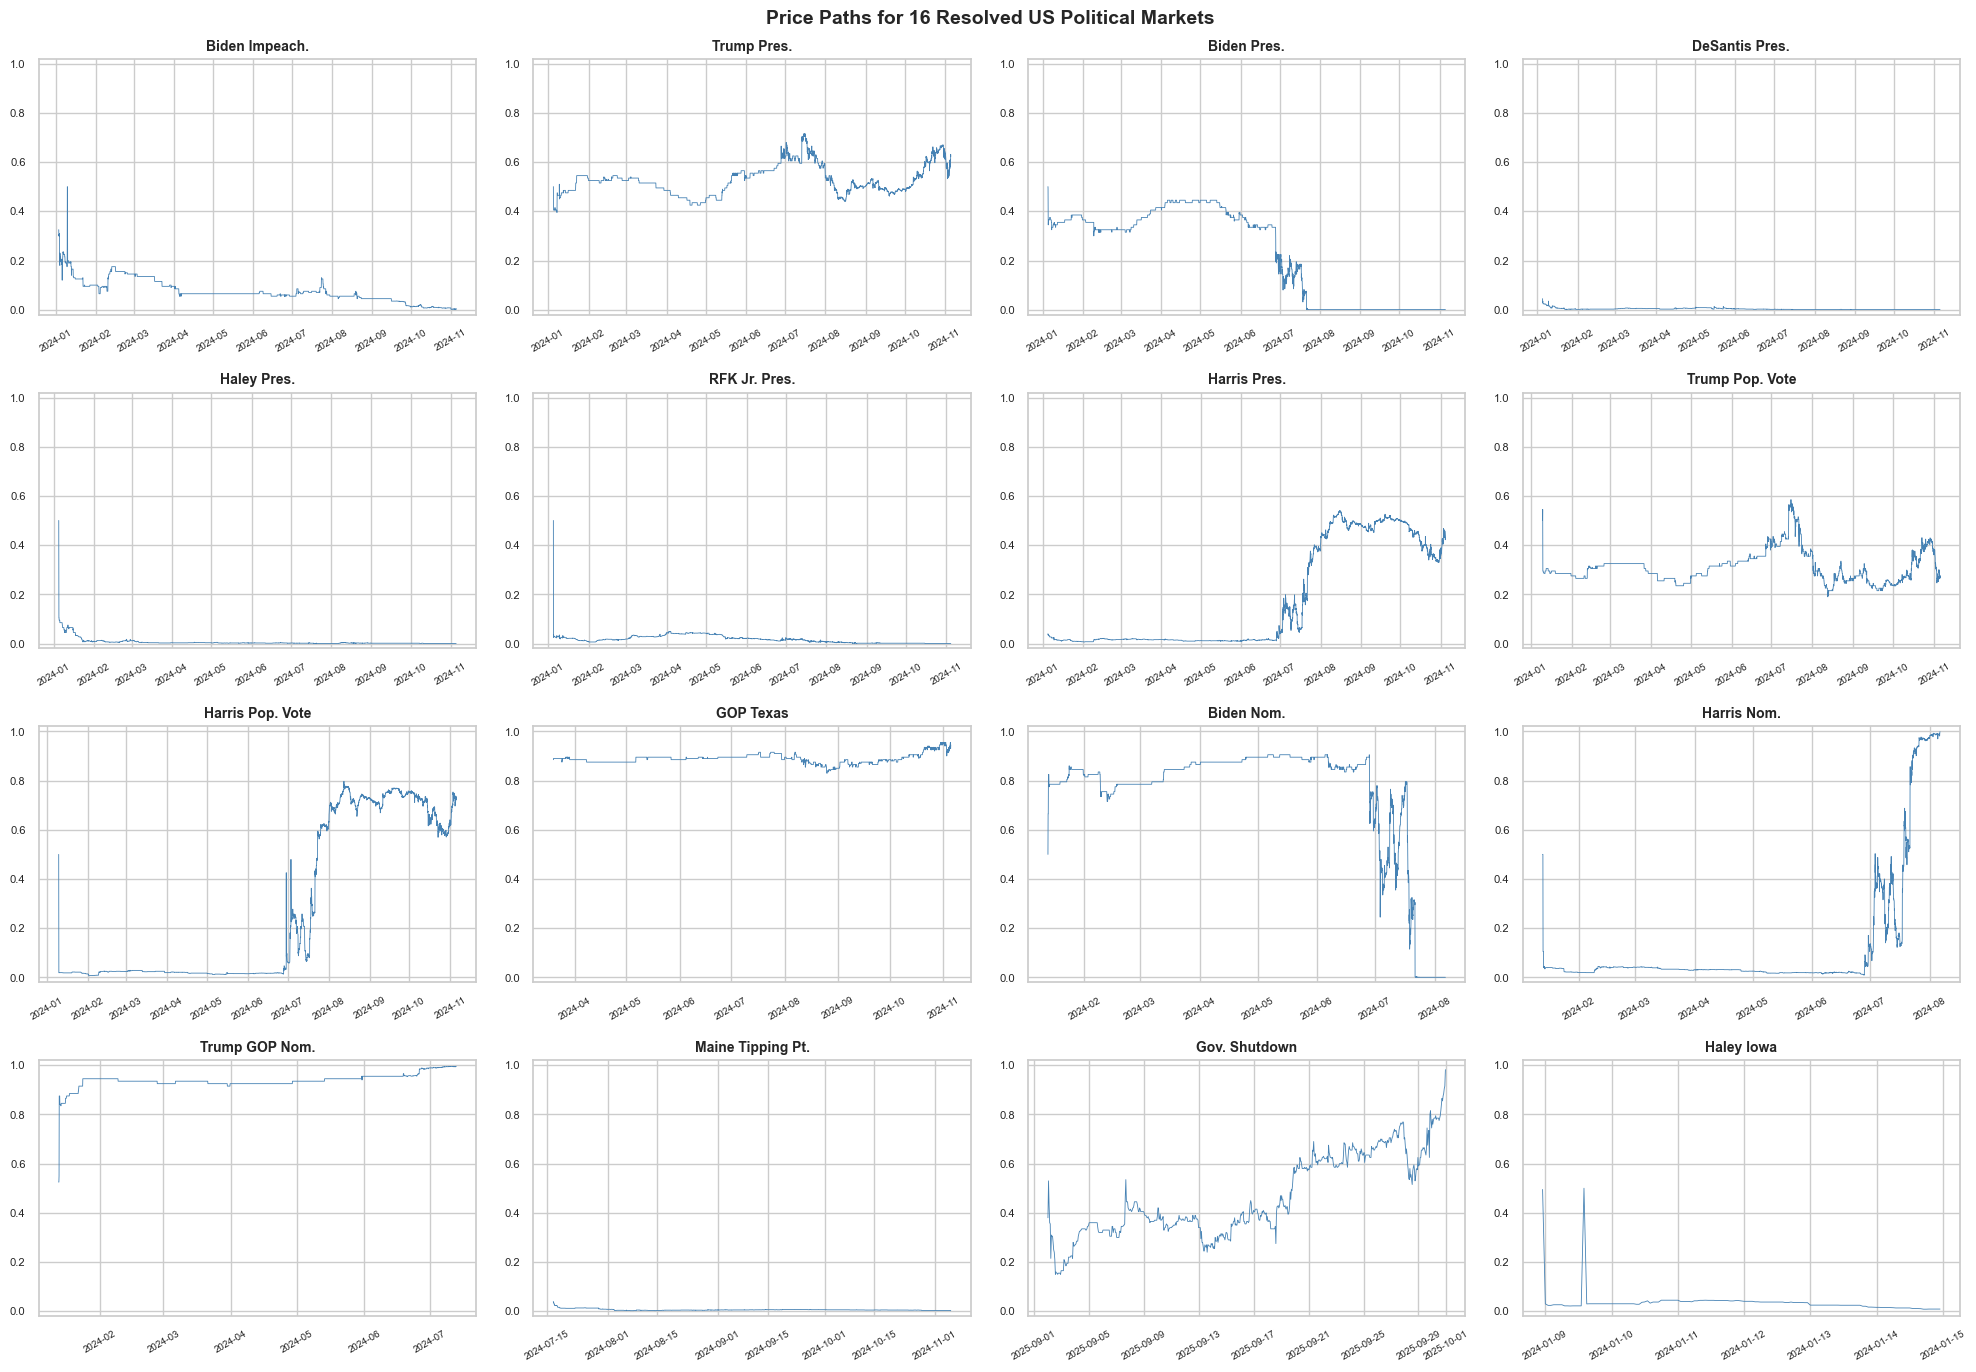

In [5]:
# Price paths for all 16 markets
fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=False)
axes_flat = axes.flatten()

for i, (slug, mdf) in enumerate(sorted(market_dfs.items(), key=lambda x: -len(x[1]))):
    if i >= 16:
        break
    ax = axes_flat[i]
    ax.plot(mdf['timestamp'], mdf['price'], linewidth=0.6, color='steelblue')
    ax.set_title(LABEL_MAP.get(slug, slug[:25]), fontsize=10, fontweight='bold')
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Price Paths for 16 Resolved US Political Markets', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_price_paths.png', dpi=150, bbox_inches='tight')
plt.show()

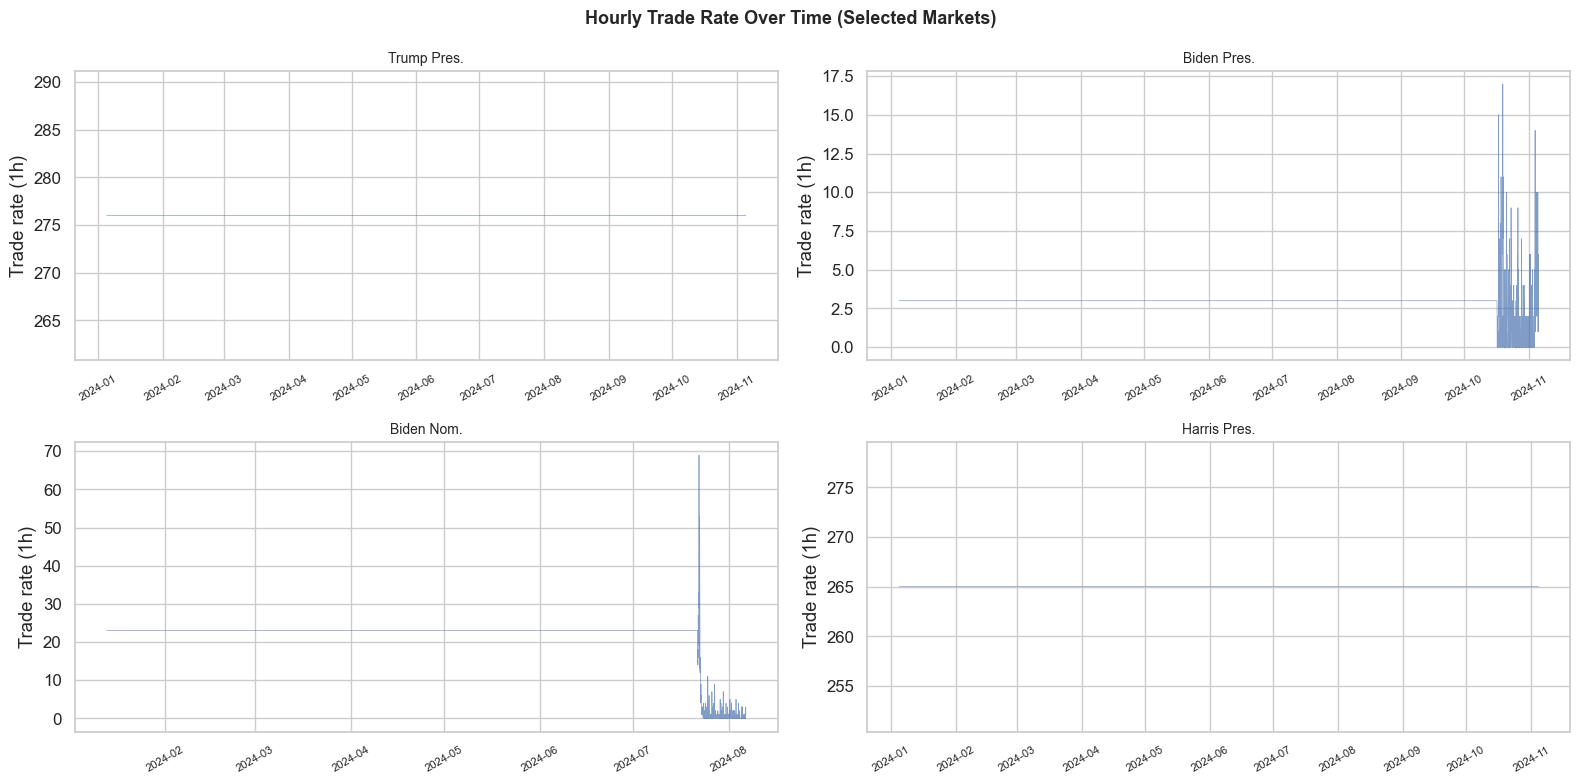

In [6]:
# Trade rate time series for a selection of markets
highlight_slugs = [
    'will-donald-trump-win-the-2024-us-presidential-election',
    'will-joe-biden-win-the-2024-us-presidential-election',
    'will-joe-biden-win-the-2024-democratic-presidential-nomination',
    'will-kamala-harris-win-the-2024-us-presidential-election',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, slug in zip(axes.flatten(), highlight_slugs):
    mdf = market_dfs[slug]
    ax.plot(mdf['timestamp'], mdf['trade_rate_1h'], linewidth=0.5, alpha=0.7)
    ax.set_title(LABEL_MAP.get(slug, slug[:30]), fontsize=10)
    ax.set_ylabel('Trade rate (1h)')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

fig.suptitle('Hourly Trade Rate Over Time (Selected Markets)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_trade_rate_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Activity–Volatility Coupling

We examine whether higher trading activity is associated with higher volatility (|logit return|), heavier tails, and stronger persistence — both across markets and within individual markets.

### 2.1 Tercile Stratification by Trade Rate

For each market, we partition hourly observations into trade-rate terciles and compute within-bin volatility statistics.

In [7]:
def compute_bin_stats(df, bin_col='trade_rate_1h', n_bins=3):
    """Compute volatility statistics within quantile bins of bin_col."""
    clean = df[['logit_return', 'abs_logit_return', bin_col]].dropna()
    if len(clean) < 30:
        return pd.DataFrame()
    clean['bin'] = pd.qcut(clean[bin_col], n_bins, labels=False, duplicates='drop')
    
    rows = []
    for b, grp in clean.groupby('bin'):
        lr = grp['logit_return']
        alr = grp['abs_logit_return']
        acf1 = float(acf(alr.values, nlags=1, fft=True)[1]) if len(alr) >= 10 else np.nan
        rows.append({
            'bin': int(b),
            'bin_lo': grp[bin_col].min(),
            'bin_hi': grp[bin_col].max(),
            'mean_abs_r': alr.mean(),
            'std_r': lr.std(),
            'kurtosis': float(sp_stats.kurtosis(lr.values)),
            'acf1_abs_r': acf1,
            'n': len(grp),
        })
    return pd.DataFrame(rows)

# Per-market tercile stats
all_tercile_stats = []
for slug, mdf in market_dfs.items():
    bs = compute_bin_stats(mdf, 'trade_rate_1h', 3)
    if not bs.empty:
        bs['market'] = LABEL_MAP.get(slug, slug[:25])
        all_tercile_stats.append(bs)

df_terciles = pd.concat(all_tercile_stats, ignore_index=True)
df_terciles['bin_label'] = df_terciles['bin'].map({0: 'Low', 1: 'Mid', 2: 'High'})
print(f'Tercile stats computed for {df_terciles["market"].nunique()} markets')
df_terciles.head(12)

Tercile stats computed for 10 markets


/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


,bin,bin_lo,bin_hi,mean_abs_r,std_r,kurtosis,acf1_abs_r,n,market,bin_label
0,0,5,161,0.005666,0.045448,377.004894,0.160826,7364,Biden Impeach.,Low
1,1,162,168,0.000000,0.000000,NaN,NaN,3,Biden Impeach.,Mid
2,0,11,16,0.004524,0.022508,55.963052,0.225262,5527,GOP Texas,Low
3,1,18,44,0.101250,0.137437,0.206155,-0.186592,12,GOP Texas,Mid
4,0,0,4,0.003511,0.034179,1601.643032,0.078702,4315,Trump GOP Nom.,Low
5,1,5,29,0.052609,0.084401,1.745569,-0.036840,51,Trump GOP Nom.,Mid
6,0,0,23,0.011326,0.079417,2038.611799,0.244161,4944,Biden Nom.,Low
7,1,25,69,0.330914,0.489114,-0.554490,-0.210809,11,Biden Nom.,Mid
8,0,0,3,0.006054,0.052599,1641.828513,0.464772,7244,Biden Pres.,Low
9,1,4,17,0.000000,0.000000,NaN,NaN,88,Biden Pres.,Mid


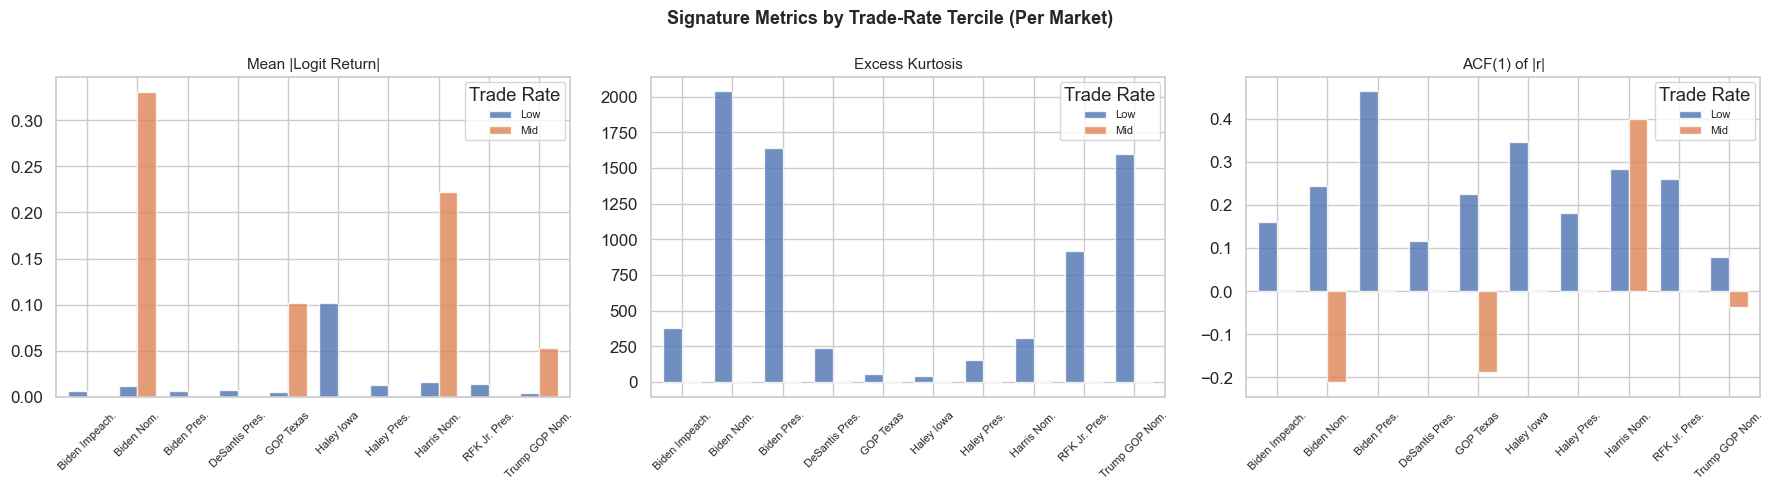

In [8]:
# Grouped bar chart: mean |r| by trade-rate tercile across markets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes, 
    ['mean_abs_r', 'kurtosis', 'acf1_abs_r'],
    ['Mean |Logit Return|', 'Excess Kurtosis', 'ACF(1) of |r|']):
    
    pivot = df_terciles.pivot_table(index='market', columns='bin_label', 
                                     values=metric, aggfunc='mean')
    if 'Low' in pivot.columns:
        pivot = pivot[['Low', 'Mid', 'High'] if 'High' in pivot.columns else 
                      [c for c in ['Low', 'Mid', 'High'] if c in pivot.columns]]
    pivot.plot(kind='bar', ax=ax, alpha=0.8, width=0.75)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(title='Trade Rate', fontsize=8)

fig.suptitle('Signature Metrics by Trade-Rate Tercile (Per Market)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_tercile_activity_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Pooled tercile analysis (all markets combined)
df_clean = df_all[['logit_return', 'abs_logit_return', 'trade_rate_1h', 'label']].dropna()
df_clean['tercile'] = pd.qcut(df_clean['trade_rate_1h'], 3, labels=['Low', 'Mid', 'High'], duplicates='drop')

pooled_stats = df_clean.groupby('tercile').agg(
    mean_abs_r=('abs_logit_return', 'mean'),
    median_abs_r=('abs_logit_return', 'median'),
    std_r=('logit_return', 'std'),
    kurtosis=('logit_return', lambda x: float(sp_stats.kurtosis(x.values))),
    n=('logit_return', 'count'),
)

print('=== Pooled Trade-Rate Tercile Statistics ===')
pooled_stats.style.format({'mean_abs_r': '{:.5f}', 'median_abs_r': '{:.5f}', 
                           'std_r': '{:.5f}', 'kurtosis': '{:.1f}', 'n': '{:,.0f}'})

=== Pooled Trade-Rate Tercile Statistics ===


,mean_abs_r,median_abs_r,std_r,kurtosis,n
tercile,,,,,
Low,0.00975,0.00000,0.06544,1260.7,"32,139"
Mid,0.00914,0.00000,0.05764,1823.8,"31,540"
High,0.00838,0.00000,0.03998,352.1,"25,368"


### 2.2 Scatter + LOWESS: Volatility vs Trade Rate

/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res

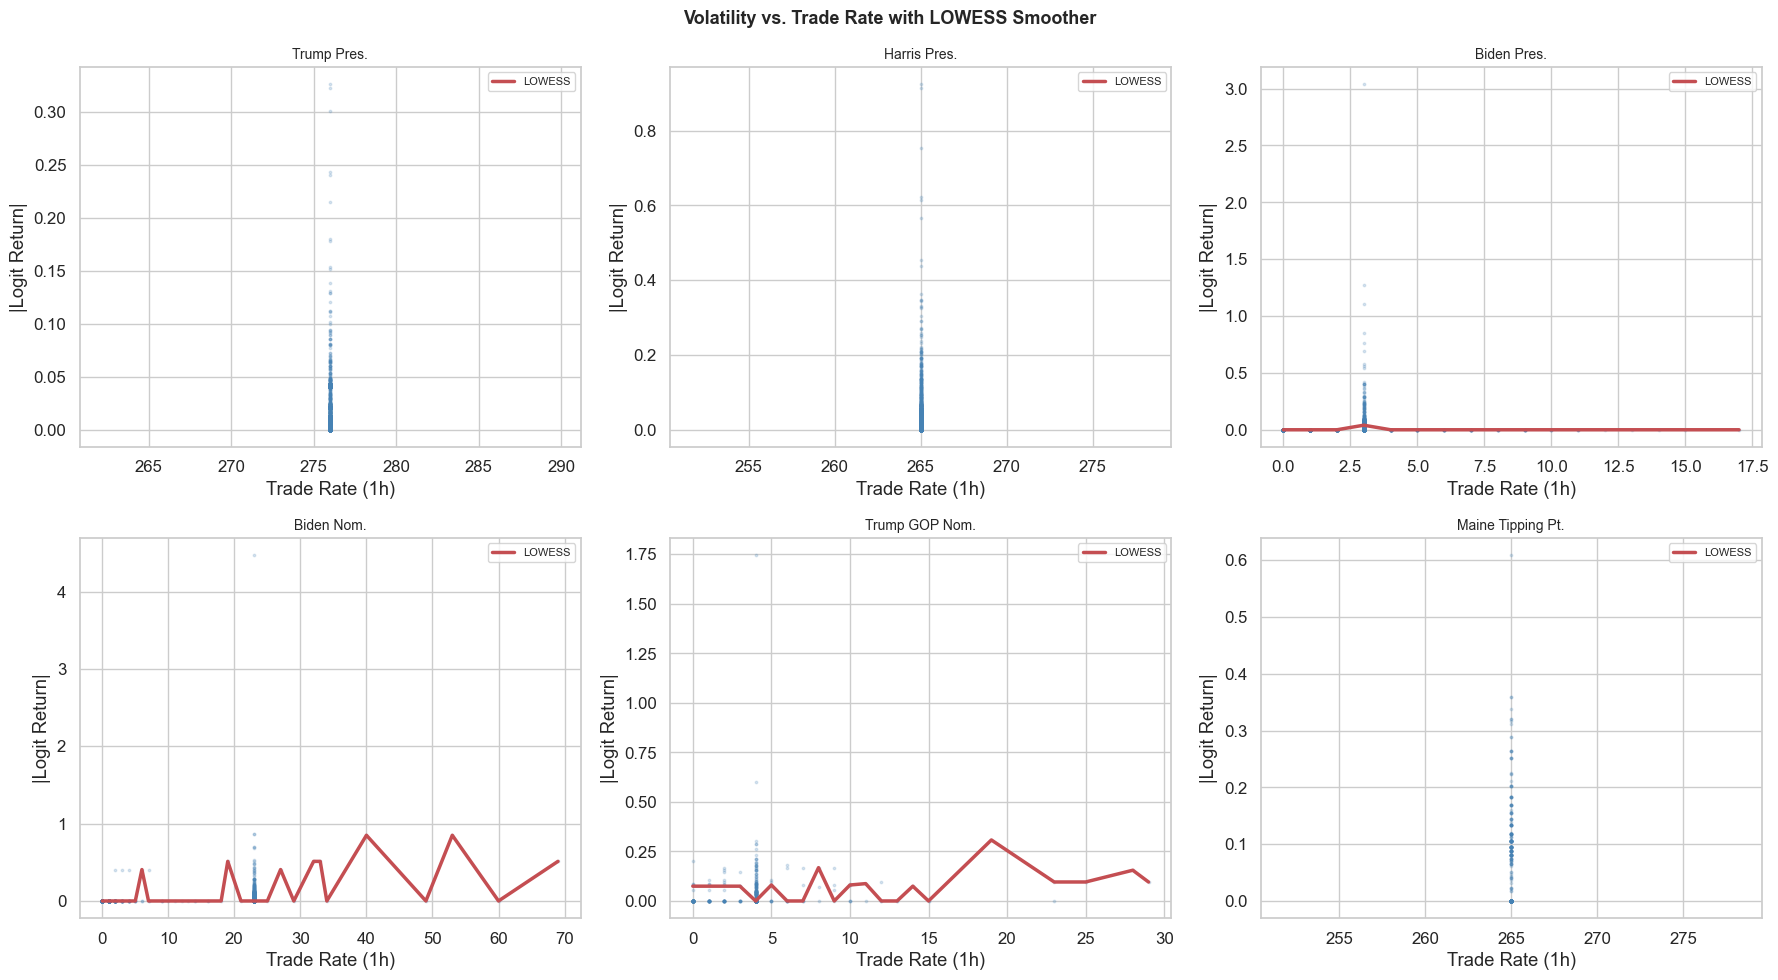

In [10]:
# Scatter + LOWESS for 6 representative markets
rep_slugs = [
    'will-donald-trump-win-the-2024-us-presidential-election',
    'will-kamala-harris-win-the-2024-us-presidential-election',
    'will-joe-biden-win-the-2024-us-presidential-election',
    'will-joe-biden-win-the-2024-democratic-presidential-nomination',
    'will-donald-j-trump-win-the-2024-republican-presidential-nomination',
    'will-maine-be-the-tipping-point-state',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, slug in zip(axes.flatten(), rep_slugs):
    mdf = market_dfs[slug][['abs_logit_return', 'trade_rate_1h']].dropna()
    if mdf.empty:
        continue
    
    ax.scatter(mdf['trade_rate_1h'], mdf['abs_logit_return'], 
               s=3, alpha=0.2, color='steelblue')
    
    lw = lowess(mdf['abs_logit_return'].values, mdf['trade_rate_1h'].values,
                frac=0.3, return_sorted=True)
    ax.plot(lw[:, 0], lw[:, 1], 'r-', linewidth=2.5, label='LOWESS')
    
    ax.set_title(LABEL_MAP.get(slug, slug[:25]), fontsize=10)
    ax.set_xlabel('Trade Rate (1h)')
    ax.set_ylabel('|Logit Return|')
    ax.legend(fontsize=8)

fig.suptitle('Volatility vs. Trade Rate with LOWESS Smoother', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_scatter_activity_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Rolling Correlation: Activity ↔ Volatility

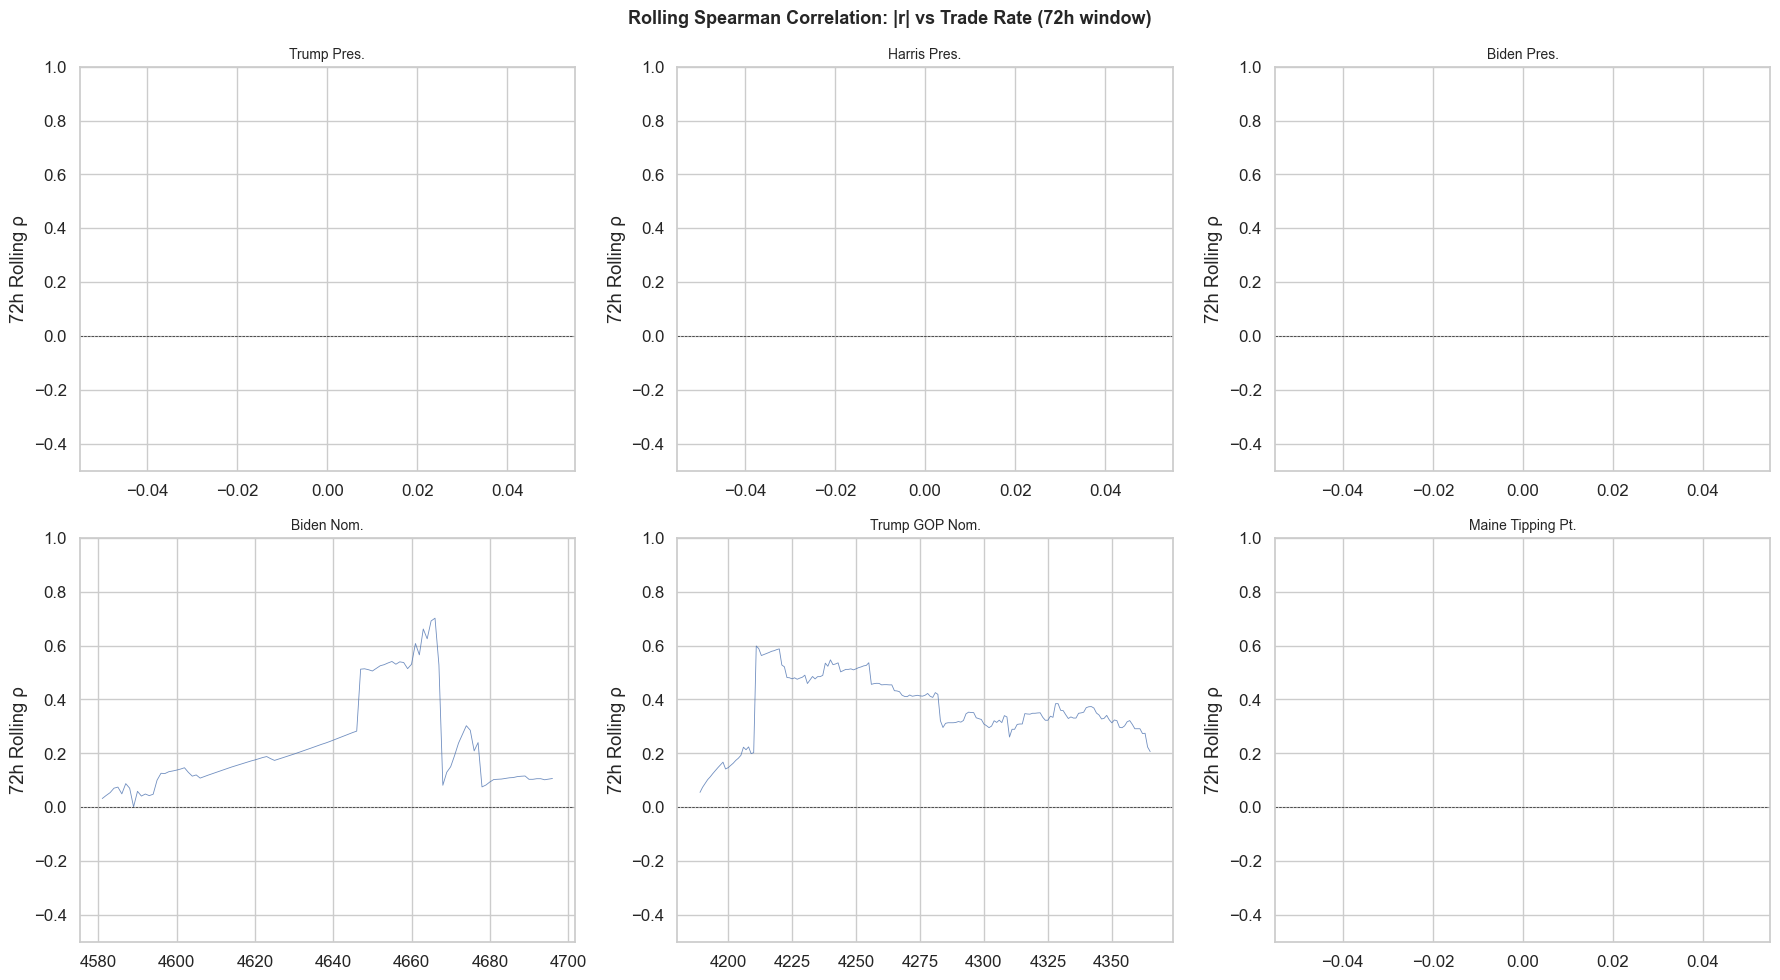

In [11]:
# 72h rolling Spearman correlation between trade_rate_1h and |logit_return|
ROLL_WINDOW = 72

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, slug in zip(axes.flatten(), rep_slugs):
    mdf = market_dfs[slug][['abs_logit_return', 'trade_rate_1h']].dropna()
    if len(mdf) < ROLL_WINDOW + 10:
        ax.set_title(f'{LABEL_MAP.get(slug, slug[:25])} (insufficient data)')
        continue
    
    roll_corr = mdf['abs_logit_return'].rolling(ROLL_WINDOW).corr(mdf['trade_rate_1h'])
    ax.plot(range(len(roll_corr)), roll_corr.values, linewidth=0.6, alpha=0.8)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_title(LABEL_MAP.get(slug, slug[:25]), fontsize=10)
    ax.set_ylabel(f'{ROLL_WINDOW}h Rolling ρ')
    ax.set_ylim(-0.5, 1)

fig.suptitle(f'Rolling Spearman Correlation: |r| vs Trade Rate ({ROLL_WINDOW}h window)', 
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_rolling_corr_activity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Deadline Effects: Signatures vs Time-to-Resolution

Do volatility, tail heaviness, and persistence intensify as markets approach their resolution date?

### 3.1 Scatter + LOWESS: Volatility vs Time-to-Resolution

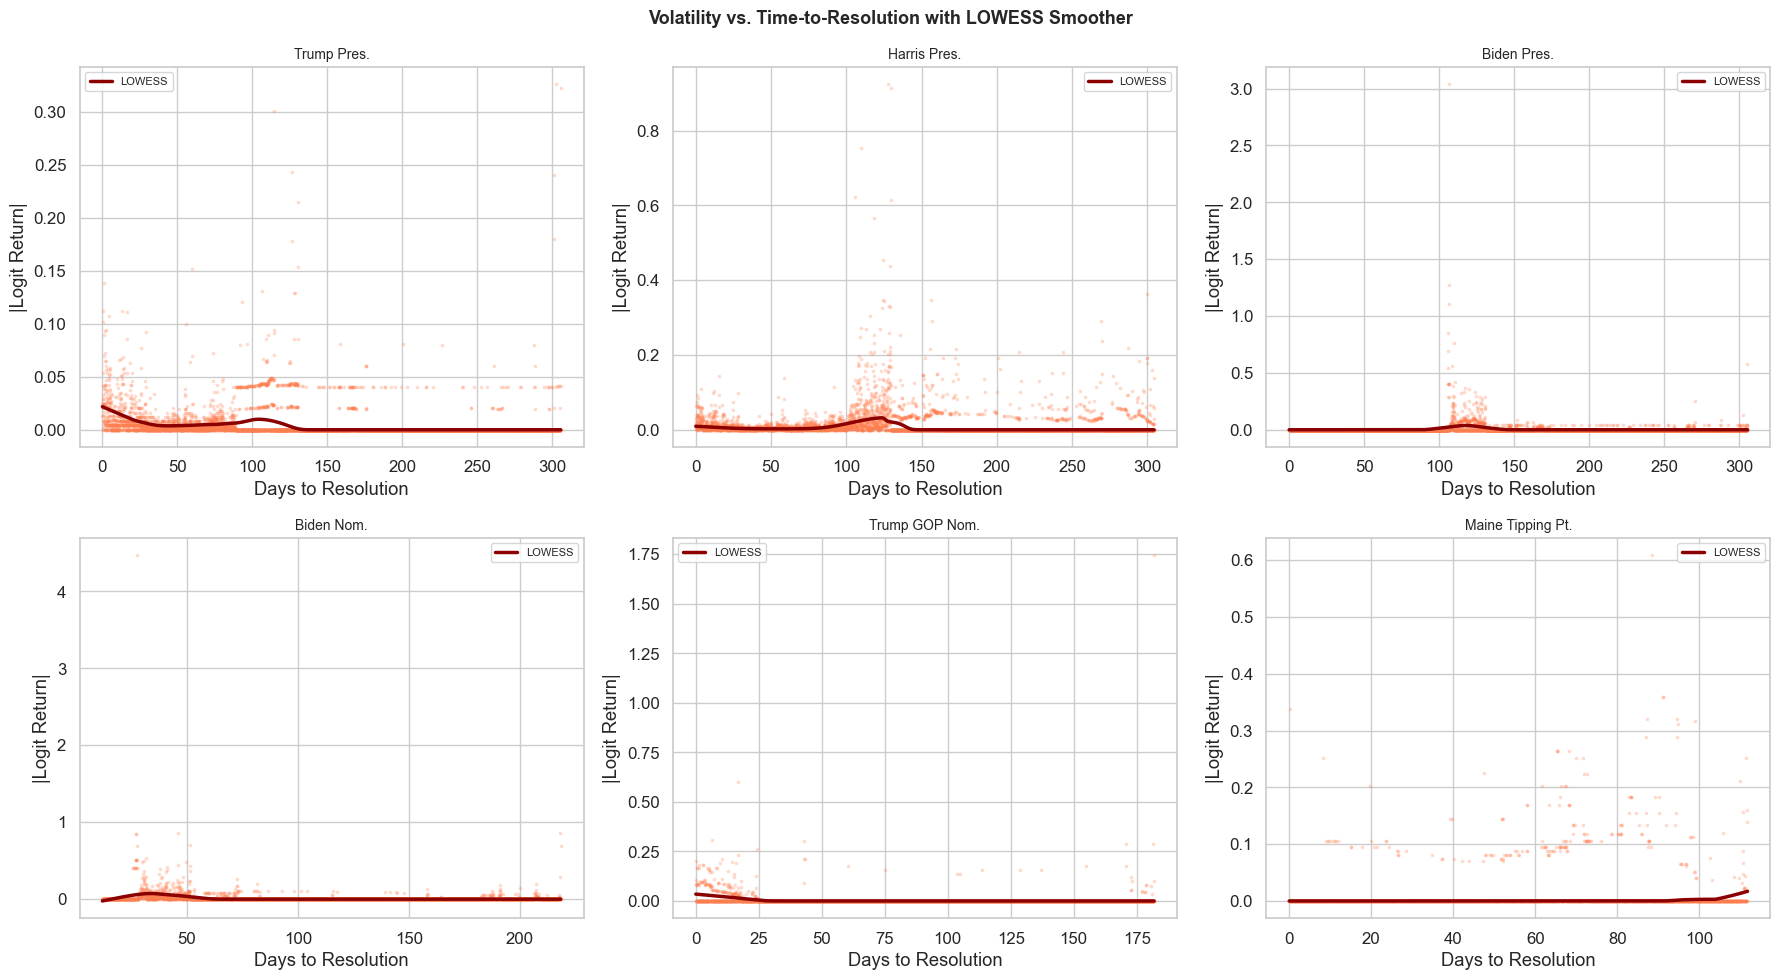

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, slug in zip(axes.flatten(), rep_slugs):
    mdf = market_dfs[slug][['abs_logit_return', 'time_to_resolution']].dropna()
    if mdf.empty:
        continue
    
    ax.scatter(mdf['time_to_resolution'], mdf['abs_logit_return'],
               s=3, alpha=0.2, color='coral')
    
    lw = lowess(mdf['abs_logit_return'].values, mdf['time_to_resolution'].values,
                frac=0.15, return_sorted=True)
    ax.plot(lw[:, 0], lw[:, 1], 'darkred', linewidth=2.5, label='LOWESS')
    
    ax.set_title(LABEL_MAP.get(slug, slug[:25]), fontsize=10)
    ax.set_xlabel('Days to Resolution')
    ax.set_ylabel('|Logit Return|')
    ax.legend(fontsize=8)

fig.suptitle('Volatility vs. Time-to-Resolution with LOWESS Smoother', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_scatter_deadline_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Time-to-Resolution Bins: How Signatures Shift Near Deadlines

We partition each market's observations into temporal bins based on time-to-resolution and compute per-bin signature statistics. This reveals whether heavy tails, volatility clustering, and mean volatility intensify near resolution.

In [13]:
# Define TTR bins: last 7d, 7-30d, 30-90d, 90-180d, 180+d
TTR_BINS = [0, 7, 30, 90, 180, 9999]
TTR_LABELS = ['0-7d', '7-30d', '30-90d', '90-180d', '180+d']

ttr_rows = []
for slug, mdf in market_dfs.items():
    clean = mdf[['logit_return', 'abs_logit_return', 'time_to_resolution']].dropna()
    clean['ttr_bin'] = pd.cut(clean['time_to_resolution'], bins=TTR_BINS, labels=TTR_LABELS, right=False)
    
    for bin_label, grp in clean.groupby('ttr_bin', observed=True):
        if len(grp) < 20:
            continue
        lr = grp['logit_return']
        alr = grp['abs_logit_return']
        
        acf1 = float(acf(alr.values, nlags=1, fft=True)[1]) if len(alr) >= 10 else np.nan
        
        try:
            lb_result = acorr_ljungbox(alr, lags=[10], return_df=True)
            lb10_p = float(lb_result['lb_pvalue'].iloc[0])
        except Exception:
            lb10_p = np.nan
        
        ttr_rows.append({
            'market': LABEL_MAP.get(slug, slug[:25]),
            'ttr_bin': bin_label,
            'n': len(grp),
            'mean_abs_r': alr.mean(),
            'std_r': lr.std(),
            'kurtosis': float(sp_stats.kurtosis(lr.values)),
            'skewness': float(sp_stats.skew(lr.values)),
            'acf1_abs_r': acf1,
            'lb10_p': lb10_p,
        })

df_ttr = pd.DataFrame(ttr_rows)
print(f'TTR bin statistics: {len(df_ttr)} rows across {df_ttr["market"].nunique()} markets')
df_ttr.head(10)

TTR bin statistics: 70 rows across 16 markets


/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dyn

,market,ttr_bin,n,mean_abs_r,std_r,kurtosis,skewness,acf1_abs_r,lb10_p
0,Biden Impeach.,0-7d,167,0.066256,0.190013,11.778593,-0.601001,0.179238,9.165010e-03
1,Biden Impeach.,7-30d,552,0.011479,0.039369,26.289203,-0.695191,0.103395,1.061997e-01
2,Biden Impeach.,30-90d,1440,0.003188,0.023750,153.852219,-7.787764,0.026355,3.215012e-13
3,Biden Impeach.,90-180d,2160,0.002700,0.020531,142.553484,2.471324,0.058696,6.018518e-04
4,Biden Impeach.,180+d,3048,0.004560,0.046671,590.805882,4.824882,0.102166,1.494125e-64
5,Gov. Shutdown,0-7d,167,0.081977,0.175540,43.579810,5.058036,0.192666,4.570330e-03
6,Gov. Shutdown,7-30d,527,0.046370,0.094102,15.618330,0.412741,0.348113,3.961993e-21
7,GOP Texas,0-7d,167,0.052055,0.092806,2.355399,-0.197591,0.093555,4.247722e-01
8,GOP Texas,7-30d,552,0.011231,0.033262,9.759210,-0.038363,0.147562,7.832937e-07
9,GOP Texas,30-90d,1440,0.005133,0.019331,28.652176,-1.671393,0.144820,9.256020e-10


In [14]:
# Pooled TTR bin summary (aggregate across markets)
pooled_ttr = df_ttr.groupby('ttr_bin').agg(
    n_market_bins=('market', 'count'),
    mean_abs_r=('mean_abs_r', 'mean'),
    mean_abs_r_se=('mean_abs_r', 'sem'),
    median_kurtosis=('kurtosis', 'median'),
    mean_acf1=('acf1_abs_r', 'mean'),
    frac_lb10_sig=('lb10_p', lambda x: (x < 0.05).mean()),
    total_obs=('n', 'sum'),
)
print('=== Pooled Time-to-Resolution Bin Summary ===')
pooled_ttr

=== Pooled Time-to-Resolution Bin Summary ===


,n_market_bins,mean_abs_r,mean_abs_r_se,median_kurtosis,mean_acf1,frac_lb10_sig,total_obs
ttr_bin,,,,,,,
0-7d,14,0.030042,0.008892,8.481201,0.179621,0.214286,2315
180+d,13,0.008138,0.003421,588.288208,0.109506,0.923077,29972
30-90d,14,0.010176,0.002659,37.889515,0.251463,0.928571,20160
7-30d,15,0.016640,0.005308,21.468850,0.190789,0.600000,7998
90-180d,14,0.009559,0.002112,107.644834,0.223236,0.928571,28602


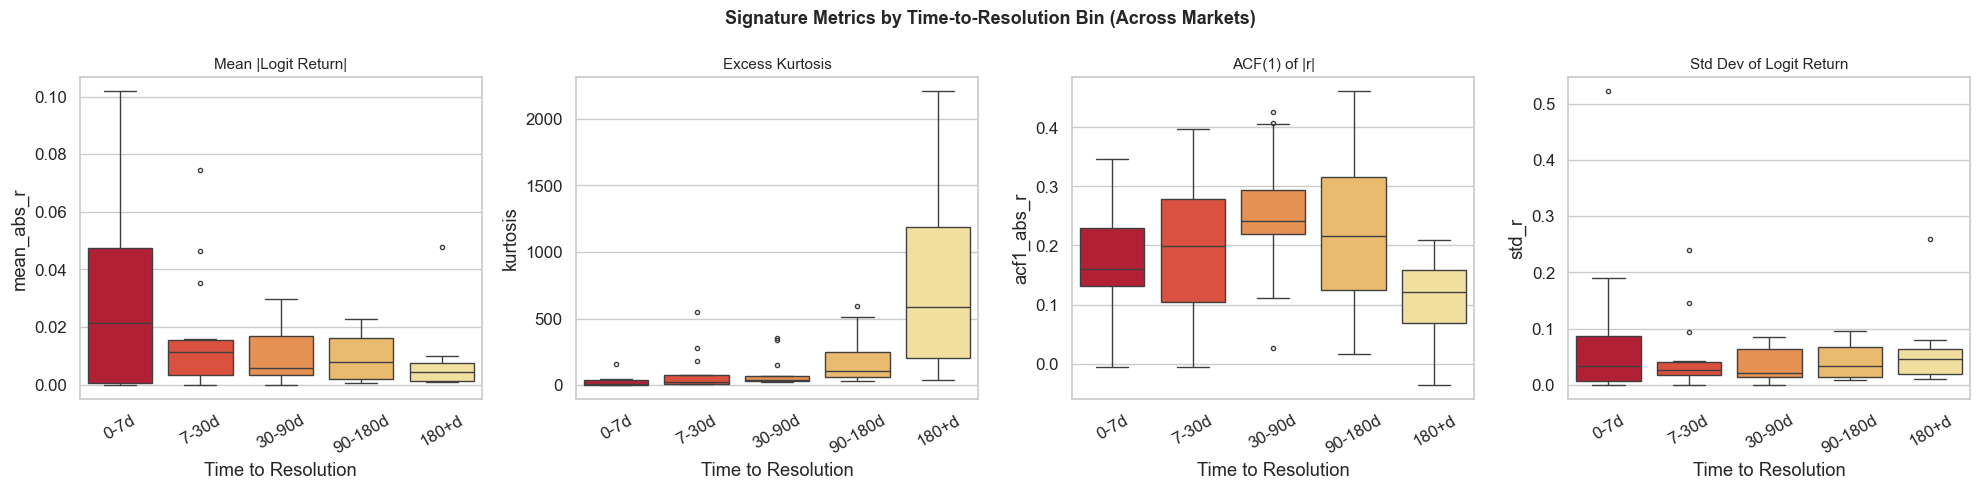

In [15]:
# Visualise TTR bin patterns
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = [
    ('mean_abs_r', 'Mean |Logit Return|'),
    ('kurtosis', 'Excess Kurtosis'),
    ('acf1_abs_r', 'ACF(1) of |r|'),
    ('std_r', 'Std Dev of Logit Return'),
]

for ax, (col, title) in zip(axes, metrics):
    sns.boxplot(data=df_ttr, x='ttr_bin', y=col, ax=ax, 
                order=TTR_LABELS, palette='YlOrRd_r', fliersize=3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Time to Resolution')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Signature Metrics by Time-to-Resolution Bin (Across Markets)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_ttr_bin_signatures.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Deadline Pressure: Last 30 Days vs Rest

A sharper comparison: do the last 30 days before resolution look different from the rest of the market's life?

In [16]:
# Compare last-30-days vs rest for each market
deadline_rows = []
for slug, mdf in market_dfs.items():
    clean = mdf[['logit_return', 'abs_logit_return', 'time_to_resolution']].dropna()
    last30 = clean[clean['time_to_resolution'] <= 30]
    rest = clean[clean['time_to_resolution'] > 30]
    
    if len(last30) < 20 or len(rest) < 20:
        continue
    
    for period, subset in [('Last 30d', last30), ('Earlier', rest)]:
        lr = subset['logit_return']
        alr = subset['abs_logit_return']
        acf1 = float(acf(alr.values, nlags=1, fft=True)[1]) if len(alr) >= 10 else np.nan
        
        deadline_rows.append({
            'market': LABEL_MAP.get(slug, slug[:25]),
            'period': period,
            'n': len(subset),
            'mean_abs_r': alr.mean(),
            'std_r': lr.std(),
            'kurtosis': float(sp_stats.kurtosis(lr.values)),
            'acf1_abs_r': acf1,
        })

df_deadline = pd.DataFrame(deadline_rows)

# Pivot for comparison
for metric in ['mean_abs_r', 'kurtosis', 'acf1_abs_r']:
    pivot = df_deadline.pivot_table(index='market', columns='period', values=metric)
    if 'Last 30d' in pivot.columns and 'Earlier' in pivot.columns:
        pivot['ratio'] = pivot['Last 30d'] / pivot['Earlier']
        print(f'\n=== {metric}: Last 30d / Earlier ===')
        print(pivot.sort_values('ratio', ascending=False).to_string(float_format='{:.4f}'.format))


=== mean_abs_r: Last 30d / Earlier ===
period             Earlier  Last 30d   ratio
market                                      
Trump GOP Nom.      0.0015    0.0172 11.4963
GOP Texas           0.0024    0.0207  8.8001
Biden Impeach.      0.0037    0.0242  6.6277
Harris Nom.         0.0119    0.0745  6.2521
Trump Pop. Vote     0.0039    0.0167  4.3091
Trump Pres.         0.0033    0.0129  3.8492
Biden Nom.          0.0098    0.0355  3.6331
Harris Pop. Vote    0.0085    0.0174  2.0573
Harris Pres.        0.0106    0.0113  1.0692
Maine Tipping Pt.   0.0115    0.0040  0.3433
Haley Pres.         0.0140    0.0017  0.1208
RFK Jr. Pres.       0.0148    0.0006  0.0381
Biden Pres.         0.0066    0.0000  0.0000
DeSantis Pres.      0.0085    0.0000  0.0000

=== kurtosis: Last 30d / Earlier ===
period              Earlier  Last 30d  ratio
market                                      
Biden Nom.         123.3467  275.8443 2.2363
Maine Tipping Pt.   36.8526   80.3853 2.1813
Haley Pres.        142

/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


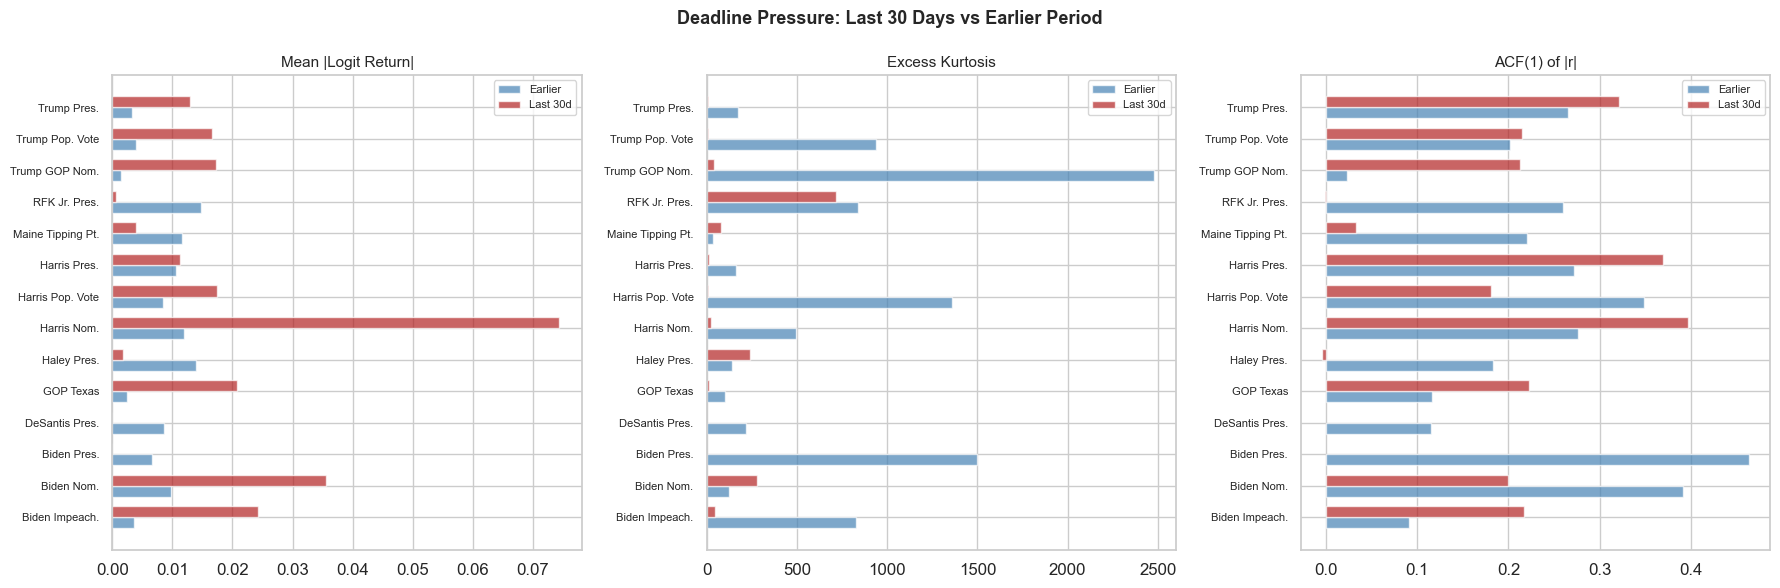

In [17]:
# Paired comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, title in zip(axes, 
    ['mean_abs_r', 'kurtosis', 'acf1_abs_r'],
    ['Mean |Logit Return|', 'Excess Kurtosis', 'ACF(1) of |r|']):
    
    pivot = df_deadline.pivot_table(index='market', columns='period', values=metric)
    if 'Last 30d' not in pivot.columns or 'Earlier' not in pivot.columns:
        continue
    
    markets = pivot.index
    x = np.arange(len(markets))
    width = 0.35
    
    ax.barh(x - width/2, pivot['Earlier'], width, label='Earlier', alpha=0.7, color='steelblue')
    ax.barh(x + width/2, pivot['Last 30d'], width, label='Last 30d', alpha=0.7, color='firebrick')
    ax.set_yticks(x)
    ax.set_yticklabels(markets, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Deadline Pressure: Last 30 Days vs Earlier Period', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_deadline_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Interaction Effects: Activity × Deadline

Does the activity–volatility coupling strengthen near the deadline? We cross-stratify by both trade rate and time-to-resolution.

In [18]:
# Cross-stratification: 2 TTR bins × 3 activity terciles
df_cross = df_all[['logit_return', 'abs_logit_return', 'trade_rate_1h', 
                     'time_to_resolution', 'label']].dropna()

df_cross['ttr_phase'] = np.where(df_cross['time_to_resolution'] <= 30, 'Last 30d', 'Earlier')
df_cross['activity_bin'] = pd.qcut(df_cross['trade_rate_1h'], 3, 
                                    labels=['Low', 'Mid', 'High'], duplicates='drop')

interaction = df_cross.groupby(['ttr_phase', 'activity_bin']).agg(
    mean_abs_r=('abs_logit_return', 'mean'),
    std_r=('logit_return', 'std'),
    kurtosis=('logit_return', lambda x: float(sp_stats.kurtosis(x.values))),
    n=('logit_return', 'count'),
).round(5)

print('=== Cross-Stratification: TTR Phase × Activity Tercile ===')
interaction

=== Cross-Stratification: TTR Phase × Activity Tercile ===


mean_abs_r    std_r    kurtosis      n
ttr_phase activity_bin                                        
Earlier   Low              0.00918  0.05644   859.76438  27990
          Mid              0.00788  0.05069  1220.55665  28924
          High             0.00636  0.03284   451.96505  21806
Last 30d  Low              0.01353  0.10808   880.04688   4149
          Mid              0.02299  0.10795  1129.74453   2616
          High             0.02077  0.06918   137.81498   3562

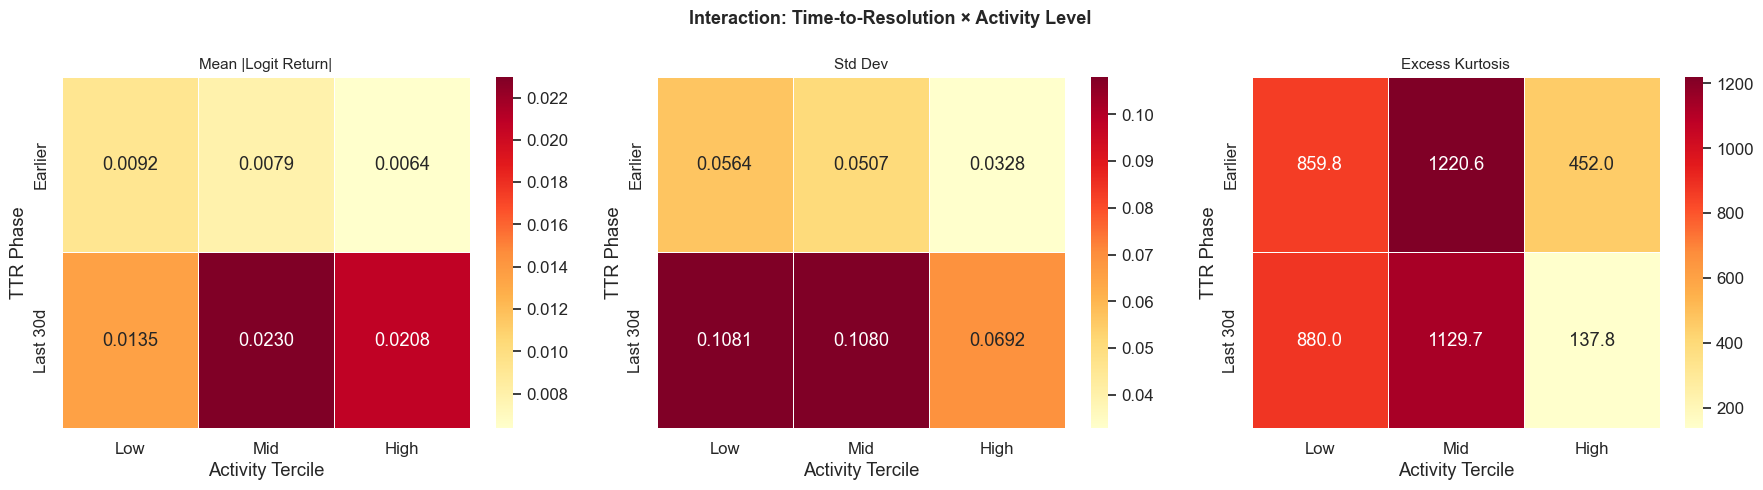

In [19]:
# Heatmap of interaction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes,
    ['mean_abs_r', 'std_r', 'kurtosis'],
    ['Mean |Logit Return|', 'Std Dev', 'Excess Kurtosis']):
    
    pivot = interaction[metric].unstack('activity_bin')
    if hasattr(pivot.columns, 'reindex'):
        try:
            pivot = pivot[['Low', 'Mid', 'High']]
        except KeyError:
            pass
    
    sns.heatmap(pivot, annot=True, fmt='.4f' if metric != 'kurtosis' else '.1f',
                cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('TTR Phase')
    ax.set_xlabel('Activity Tercile')

fig.suptitle('Interaction: Time-to-Resolution × Activity Level', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Regression Analysis

We estimate pooled and per-market models relating volatility to activity and deadline proxies.

### 5.1 Pooled OLS with Market Fixed Effects

In [20]:
# Pooled OLS: |r| ~ trade_rate_1h + time_to_resolution + market dummies
reg_cols = ['abs_logit_return', 'trade_rate_1h', 'time_to_resolution', 'label']
df_reg = df_all[reg_cols].dropna()

y = df_reg['abs_logit_return']
X = df_reg[['trade_rate_1h', 'time_to_resolution']].copy()

# Market dummies (fixed effects)
market_dummies = pd.get_dummies(df_reg['label'], drop_first=True, dtype=float)
X = pd.concat([X, market_dummies], axis=1)
X = sm.add_constant(X)

model_pooled = sm.OLS(y, X).fit(cov_type='HC1')

print('=== Pooled OLS: |logit_return| ~ trade_rate_1h + time_to_resolution + market FE ===')
print(f'N = {model_pooled.nobs:,.0f}    R² = {model_pooled.rsquared:.4f}    Adj-R² = {model_pooled.rsquared_adj:.4f}')
print()

# Show only key coefficients (not all market dummies)
key_params = ['const', 'trade_rate_1h', 'time_to_resolution']
coef_table = pd.DataFrame({
    'coef': model_pooled.params[key_params],
    'se': model_pooled.bse[key_params],
    't': model_pooled.tvalues[key_params],
    'p': model_pooled.pvalues[key_params],
    'ci_lo': model_pooled.conf_int().loc[key_params, 0],
    'ci_hi': model_pooled.conf_int().loc[key_params, 1],
})
print(coef_table.to_string(float_format='{:.6f}'.format))
print(f'\nJarque-Bera on residuals: {sp_stats.jarque_bera(model_pooled.resid).statistic:.2e} '
      f'(p={sp_stats.jarque_bera(model_pooled.resid).pvalue:.4f})')
print(f'Residual kurtosis: {sp_stats.kurtosis(model_pooled.resid):.1f}')

=== Pooled OLS: |logit_return| ~ trade_rate_1h + time_to_resolution + market FE ===
N = 89,047    R² = 0.0169    Adj-R² = 0.0167

                        coef       se          t        p     ci_lo     ci_hi
const              -0.017140 0.049429  -0.346766 0.728767 -0.114018  0.079738
trade_rate_1h       0.000175 0.000308   0.567418 0.570430 -0.000428  0.000778
time_to_resolution -0.000034 0.000003 -13.292953 0.000000 -0.000039 -0.000029

Jarque-Bera on residuals: 9.73e+09 (p=0.0000)
Residual kurtosis: 1617.9


### 5.2 Pooled OLS with Interaction Term

In [21]:
# Add interaction: trade_rate × time_to_resolution
df_reg2 = df_all[['abs_logit_return', 'trade_rate_1h', 'time_to_resolution', 'label']].dropna()

y2 = df_reg2['abs_logit_return']
X2 = df_reg2[['trade_rate_1h', 'time_to_resolution']].copy()
X2['trade_x_ttr'] = X2['trade_rate_1h'] * X2['time_to_resolution']
dummies2 = pd.get_dummies(df_reg2['label'], drop_first=True, dtype=float)
X2 = pd.concat([X2, dummies2], axis=1)
X2 = sm.add_constant(X2)

model_interact = sm.OLS(y2, X2).fit(cov_type='HC1')

print('=== Pooled OLS with Interaction Term ===')
print(f'N = {model_interact.nobs:,.0f}    R² = {model_interact.rsquared:.4f}    Adj-R² = {model_interact.rsquared_adj:.4f}')
print()

key_params2 = ['const', 'trade_rate_1h', 'time_to_resolution', 'trade_x_ttr']
coef_table2 = pd.DataFrame({
    'coef': model_interact.params[key_params2],
    'se': model_interact.bse[key_params2],
    't': model_interact.tvalues[key_params2],
    'p': model_interact.pvalues[key_params2],
})
print(coef_table2.to_string(float_format='{:.6f}'.format))

=== Pooled OLS with Interaction Term ===
N = 89,047    R² = 0.0169    Adj-R² = 0.0167

                        coef       se         t        p
const              -0.017737 0.049700 -0.356870 0.721189
trade_rate_1h       0.000177 0.000309  0.572864 0.566737
time_to_resolution -0.000036 0.000004 -9.734159 0.000000
trade_x_ttr         0.000000 0.000000  1.028203 0.303855


### 5.3 Per-Market OLS Regressions

In [22]:
# Per-market OLS: |r| ~ trade_rate_1h + time_to_resolution
per_market_results = []
for slug, mdf in market_dfs.items():
    clean = mdf[['abs_logit_return', 'trade_rate_1h', 'time_to_resolution']].dropna()
    if len(clean) < 50:
        continue
    
    y_m = clean['abs_logit_return']
    X_m = sm.add_constant(clean[['trade_rate_1h', 'time_to_resolution']])
    
    try:
        res = sm.OLS(y_m, X_m).fit(cov_type='HC1')
        per_market_results.append({
            'market': LABEL_MAP.get(slug, slug[:25]),
            'n': int(res.nobs),
            'R2': res.rsquared,
            'trade_rate_coef': res.params.get('trade_rate_1h', np.nan),
            'trade_rate_p': res.pvalues.get('trade_rate_1h', np.nan),
            'ttr_coef': res.params.get('time_to_resolution', np.nan),
            'ttr_p': res.pvalues.get('time_to_resolution', np.nan),
        })
    except Exception:
        continue

df_per_mkt = pd.DataFrame(per_market_results).sort_values('R2', ascending=False)

print('=== Per-Market OLS: |r| ~ trade_rate_1h + time_to_resolution ===')
df_per_mkt.style.format({
    'R2': '{:.4f}', 'trade_rate_coef': '{:.6f}', 'trade_rate_p': '{:.4f}',
    'ttr_coef': '{:.6f}', 'ttr_p': '{:.4f}',
}).map(lambda v: 'color: red' if isinstance(v, (int, float)) and v < 0.05 else '', 
      subset=['trade_rate_p', 'ttr_p'])

=== Per-Market OLS: |r| ~ trade_rate_1h + time_to_resolution ===


,market,n,R2,trade_rate_coef,trade_rate_p,ttr_coef,ttr_p
8,Harris Nom.,4950,0.1267,0.008053,0.0000,-0.000278,0.0000
2,GOP Texas,5539,0.0759,0.005546,0.0006,-0.000071,0.0000
12,Haley Iowa,144,0.0489,0.019343,0.1248,0.066498,0.0576
4,Trump Pres.,7332,0.0398,0.000034,0.0000,-0.000033,0.0000
5,Trump Pop. Vote,7212,0.0393,0.000156,0.0000,-0.000046,0.0000
6,Biden Nom.,4955,0.0376,0.002010,0.0000,-0.000282,0.0000
0,Biden Impeach.,7367,0.0311,-0.001167,0.0029,-0.000018,0.0422
3,Trump GOP Nom.,4366,0.0193,0.003430,0.0004,-0.000061,0.0002
1,Gov. Shutdown,694,0.0164,0.000180,0.0000,-0.001622,0.0206
11,Maine Tipping Pt.,2681,0.0102,0.000010,0.0103,0.000122,0.0000


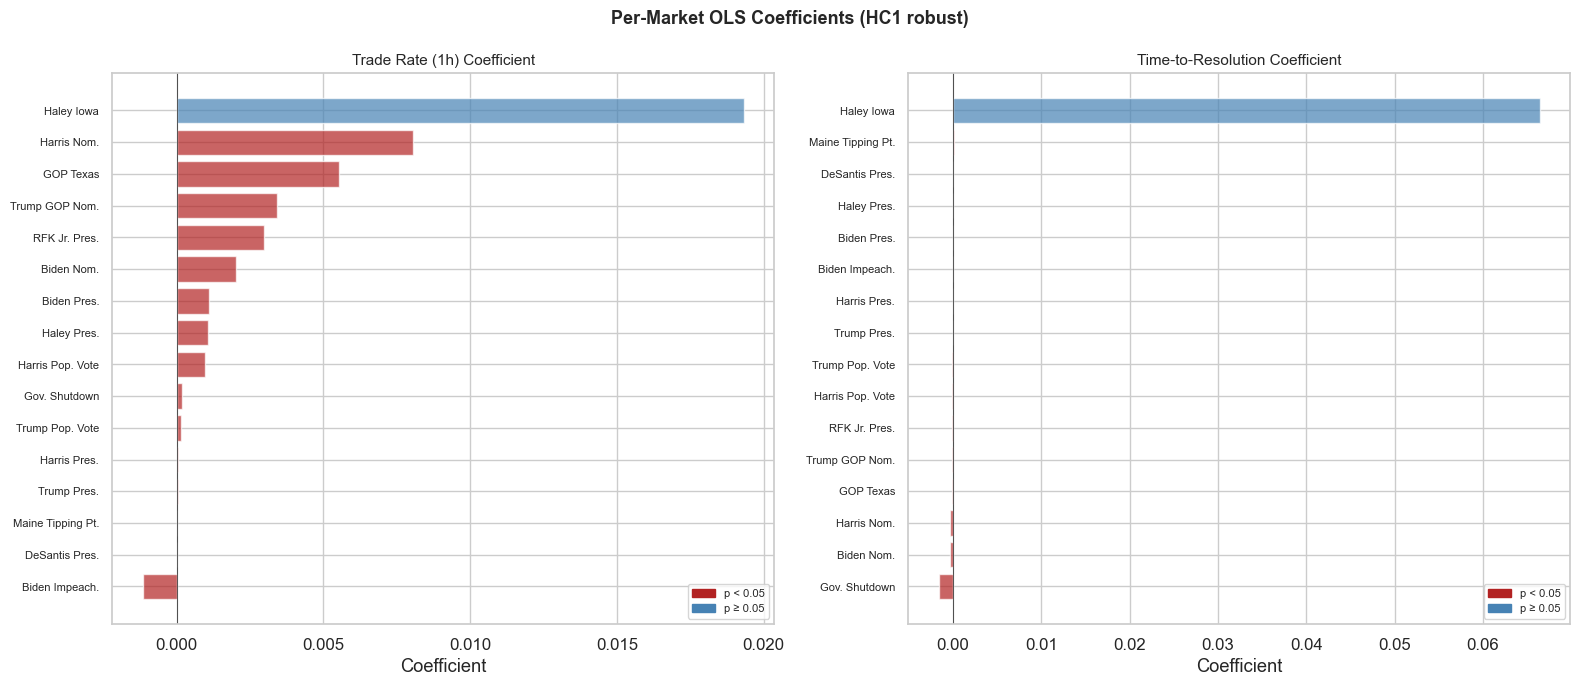

In [23]:
# Forest plot of per-market trade_rate coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coef_col, p_col, title in zip(axes,
    ['trade_rate_coef', 'ttr_coef'],
    ['trade_rate_p', 'ttr_p'],
    ['Trade Rate (1h) Coefficient', 'Time-to-Resolution Coefficient']):
    
    sorted_df = df_per_mkt.sort_values(coef_col)
    colors = ['firebrick' if p < 0.05 else 'steelblue' for p in sorted_df[p_col]]
    y_pos = np.arange(len(sorted_df))
    
    ax.barh(y_pos, sorted_df[coef_col], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_df['market'], fontsize=8)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Coefficient')
    
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='firebrick', label='p < 0.05'),
                       Patch(color='steelblue', label='p ≥ 0.05')], fontsize=8)

fig.suptitle('Per-Market OLS Coefficients (HC1 robust)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_per_market_ols_forest.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Quantile Regression: Tail Sensitivity

OLS estimates the conditional mean of |r|. Quantile regression at τ = 0.90 and τ = 0.95 tests whether the *tails* of the volatility distribution respond differently to activity and deadline pressure.

In [24]:
# Quantile regression at selected quantiles
df_qr = df_all[['abs_logit_return', 'trade_rate_1h', 'time_to_resolution']].dropna()

y_qr = df_qr['abs_logit_return']
X_qr = sm.add_constant(df_qr[['trade_rate_1h', 'time_to_resolution']])

quantiles = [0.50, 0.75, 0.90, 0.95]
qr_results = []

for q in quantiles:
    qr_model = sm.QuantReg(y_qr, X_qr).fit(q=q)
    qr_results.append({
        'quantile': q,
        'trade_rate_coef': qr_model.params['trade_rate_1h'],
        'trade_rate_p': qr_model.pvalues['trade_rate_1h'],
        'ttr_coef': qr_model.params['time_to_resolution'],
        'ttr_p': qr_model.pvalues['time_to_resolution'],
        'pseudo_R2': qr_model.prsquared,
    })

df_qr_results = pd.DataFrame(qr_results)
print('=== Quantile Regression: |r| ~ trade_rate_1h + time_to_resolution ===')
df_qr_results.style.format({
    'trade_rate_coef': '{:.6f}', 'trade_rate_p': '{:.4f}',
    'ttr_coef': '{:.6f}', 'ttr_p': '{:.4f}', 'pseudo_R2': '{:.4f}',
})

=== Quantile Regression: |r| ~ trade_rate_1h + time_to_resolution ===


,quantile,trade_rate_coef,trade_rate_p,ttr_coef,ttr_p,pseudo_R2
0,0.500000,0.000000,0.0000,-0.000000,0.0000,-0.0000
1,0.750000,0.000002,0.0000,-0.000000,0.0000,-0.0002
2,0.900000,0.000007,0.0000,-0.000099,0.0000,0.0326
3,0.950000,0.000026,0.0159,-0.000218,0.0000,0.0226


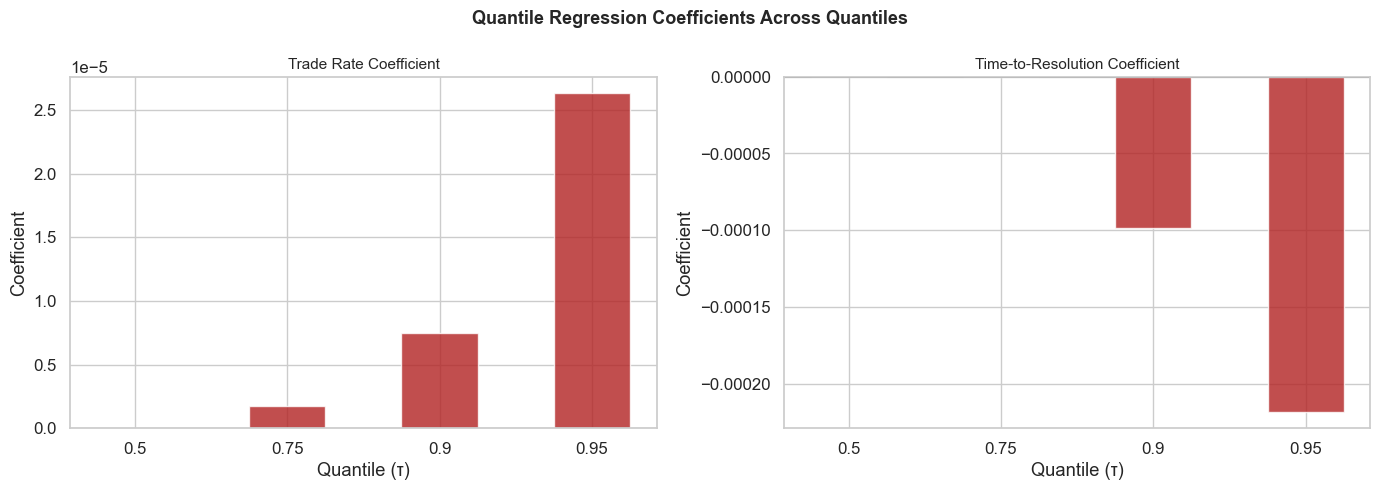

In [25]:
# Quantile regression coefficient progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, coef_col, p_col, title in zip(axes,
    ['trade_rate_coef', 'ttr_coef'],
    ['trade_rate_p', 'ttr_p'],
    ['Trade Rate Coefficient', 'Time-to-Resolution Coefficient']):
    
    colors = ['firebrick' if p < 0.05 else 'grey' for p in df_qr_results[p_col]]
    ax.bar(df_qr_results['quantile'].astype(str), df_qr_results[coef_col], 
           color=colors, alpha=0.8, width=0.5)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Quantile (τ)')
    ax.set_ylabel('Coefficient')
    ax.set_title(title, fontsize=11)

fig.suptitle('Quantile Regression Coefficients Across Quantiles', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_quantile_regression.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Signature Variation by Market Type

Do different political market types (presidential, nomination, state-level, policy) exhibit different sensitivity to activity and deadline conditions?

In [26]:
# Per-market-type OLS
type_results = []
for mtype, grp in df_all.groupby('market_type'):
    clean = grp[['abs_logit_return', 'trade_rate_1h', 'time_to_resolution']].dropna()
    if len(clean) < 100:
        continue
    
    y_t = clean['abs_logit_return']
    X_t = sm.add_constant(clean[['trade_rate_1h', 'time_to_resolution']])
    res = sm.OLS(y_t, X_t).fit(cov_type='HC1')
    
    type_results.append({
        'market_type': mtype,
        'n': int(res.nobs),
        'R2': res.rsquared,
        'trade_rate_coef': res.params['trade_rate_1h'],
        'trade_rate_p': res.pvalues['trade_rate_1h'],
        'ttr_coef': res.params['time_to_resolution'],
        'ttr_p': res.pvalues['time_to_resolution'],
    })

df_type = pd.DataFrame(type_results)
print('=== OLS by Market Type ===')
df_type.style.format({
    'R2': '{:.4f}', 'trade_rate_coef': '{:.6f}', 'trade_rate_p': '{:.4f}',
    'ttr_coef': '{:.6f}', 'ttr_p': '{:.4f}',
})

=== OLS by Market Type ===


,market_type,n,R2,trade_rate_coef,trade_rate_p,ttr_coef,ttr_p
0,nomination,14271,0.0415,0.001097,0.0000,-0.000213,0.0000
1,policy,8061,0.0599,0.000155,0.0000,-0.000031,0.0018
2,popular_vote,14423,0.0086,-0.000070,0.0000,-0.000046,0.0000
3,presidential,43928,0.0006,-0.000009,0.0000,-0.000006,0.0150
4,primary,144,0.0489,0.019343,0.1248,0.066498,0.0576
5,state_level,8220,0.0175,0.000006,0.1319,-0.000054,0.0000


In [27]:
# Signature comparison across market types
type_signatures = []
for mtype, grp in df_all.groupby('market_type'):
    lr = grp['logit_return'].dropna()
    alr = grp['abs_logit_return'].dropna()
    if len(lr) < 50:
        continue
    
    try:
        lb = acorr_ljungbox(alr, lags=[10, 20], return_df=True)
        lb10 = float(lb['lb_pvalue'].iloc[0])
        lb20 = float(lb['lb_pvalue'].iloc[1])
    except Exception:
        lb10 = lb20 = np.nan
    
    type_signatures.append({
        'market_type': mtype,
        'n': len(lr),
        'mean_abs_r': alr.mean(),
        'std_r': lr.std(),
        'kurtosis': float(sp_stats.kurtosis(lr.values)),
        'skewness': float(sp_stats.skew(lr.values)),
        'lb10_p': lb10,
        'lb20_p': lb20,
        'mean_trade_rate': grp['trade_rate_1h'].mean(),
    })

df_type_sig = pd.DataFrame(type_signatures)
print('=== Signature Summary by Market Type ===')
df_type_sig

=== Signature Summary by Market Type ===


,market_type,n,mean_abs_r,std_r,kurtosis,skewness,lb10_p,lb20_p,mean_trade_rate
0,nomination,14271,0.011383,0.066243,1603.709478,-21.568650,0.000000,0.000000,13.207160
1,policy,8061,0.009906,0.055753,258.664776,4.043957,0.000000,0.000000,184.350986
2,popular_vote,14423,0.007252,0.049476,2440.725054,-6.684377,0.000000,0.000000,47.002080
3,presidential,43928,0.009126,0.050858,795.460980,-11.076754,0.000000,0.000000,94.154095
4,primary,144,0.101780,0.521661,43.834795,-1.232399,0.050551,0.000119,0.351724
5,state_level,8220,0.006285,0.029815,61.721426,-0.153034,0.000000,0.000000,97.240574


---
## 7. Volatility Clustering Variation with Conditions

Does the *persistence* of volatility (not just its level) vary with activity and deadline proximity?

/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


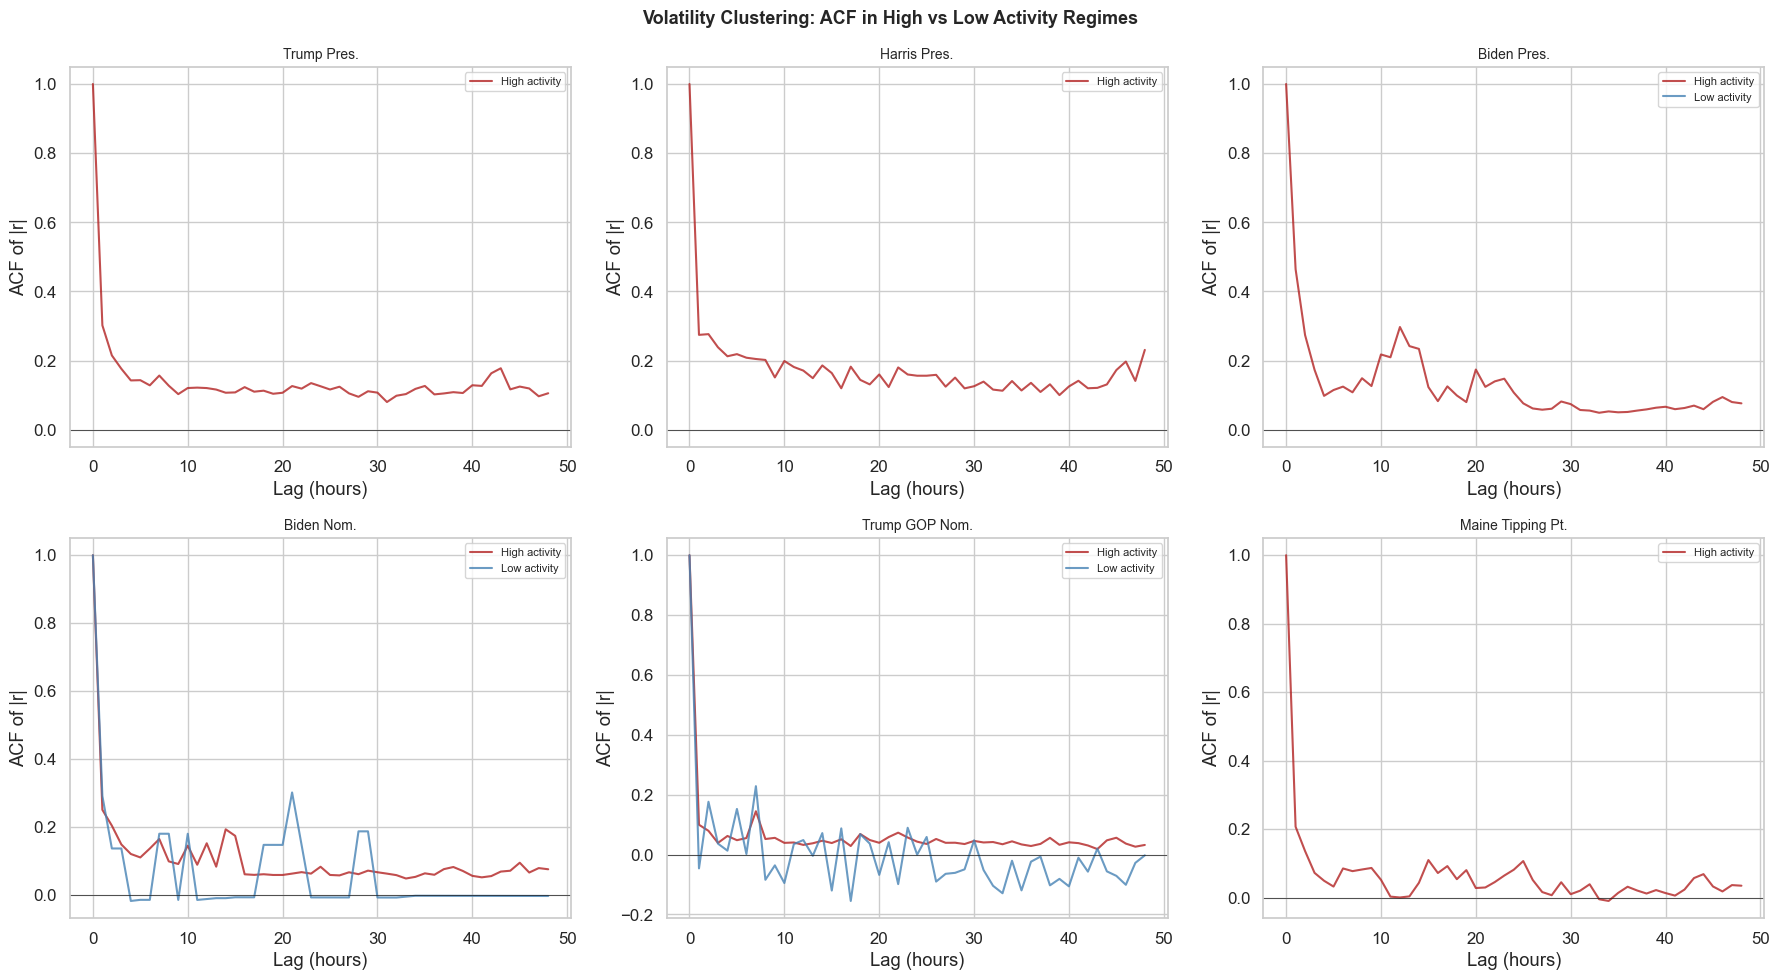

In [28]:
# ACF of |r| in high vs low activity regimes (split at median trade_rate_1h)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
NLAGS = 48

for ax, slug in zip(axes.flatten(), rep_slugs):
    mdf = market_dfs[slug][['abs_logit_return', 'trade_rate_1h']].dropna()
    if len(mdf) < 100:
        ax.set_title(f'{LABEL_MAP.get(slug, slug[:25])} (insufficient)')
        continue
    
    median_rate = mdf['trade_rate_1h'].median()
    high = mdf[mdf['trade_rate_1h'] >= median_rate]['abs_logit_return']
    low = mdf[mdf['trade_rate_1h'] < median_rate]['abs_logit_return']
    
    for series, label, color in [(high, 'High activity', 'firebrick'), 
                                  (low, 'Low activity', 'steelblue')]:
        if len(series) >= NLAGS + 5:
            acf_vals = acf(series.values, nlags=NLAGS, fft=True)
            ax.plot(range(NLAGS + 1), acf_vals, label=label, color=color, alpha=0.8)
    
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_title(LABEL_MAP.get(slug, slug[:25]), fontsize=10)
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('ACF of |r|')
    ax.legend(fontsize=8)

fig.suptitle('Volatility Clustering: ACF in High vs Low Activity Regimes', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_acf_by_activity.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Final Project/polymarket-dynamics/venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


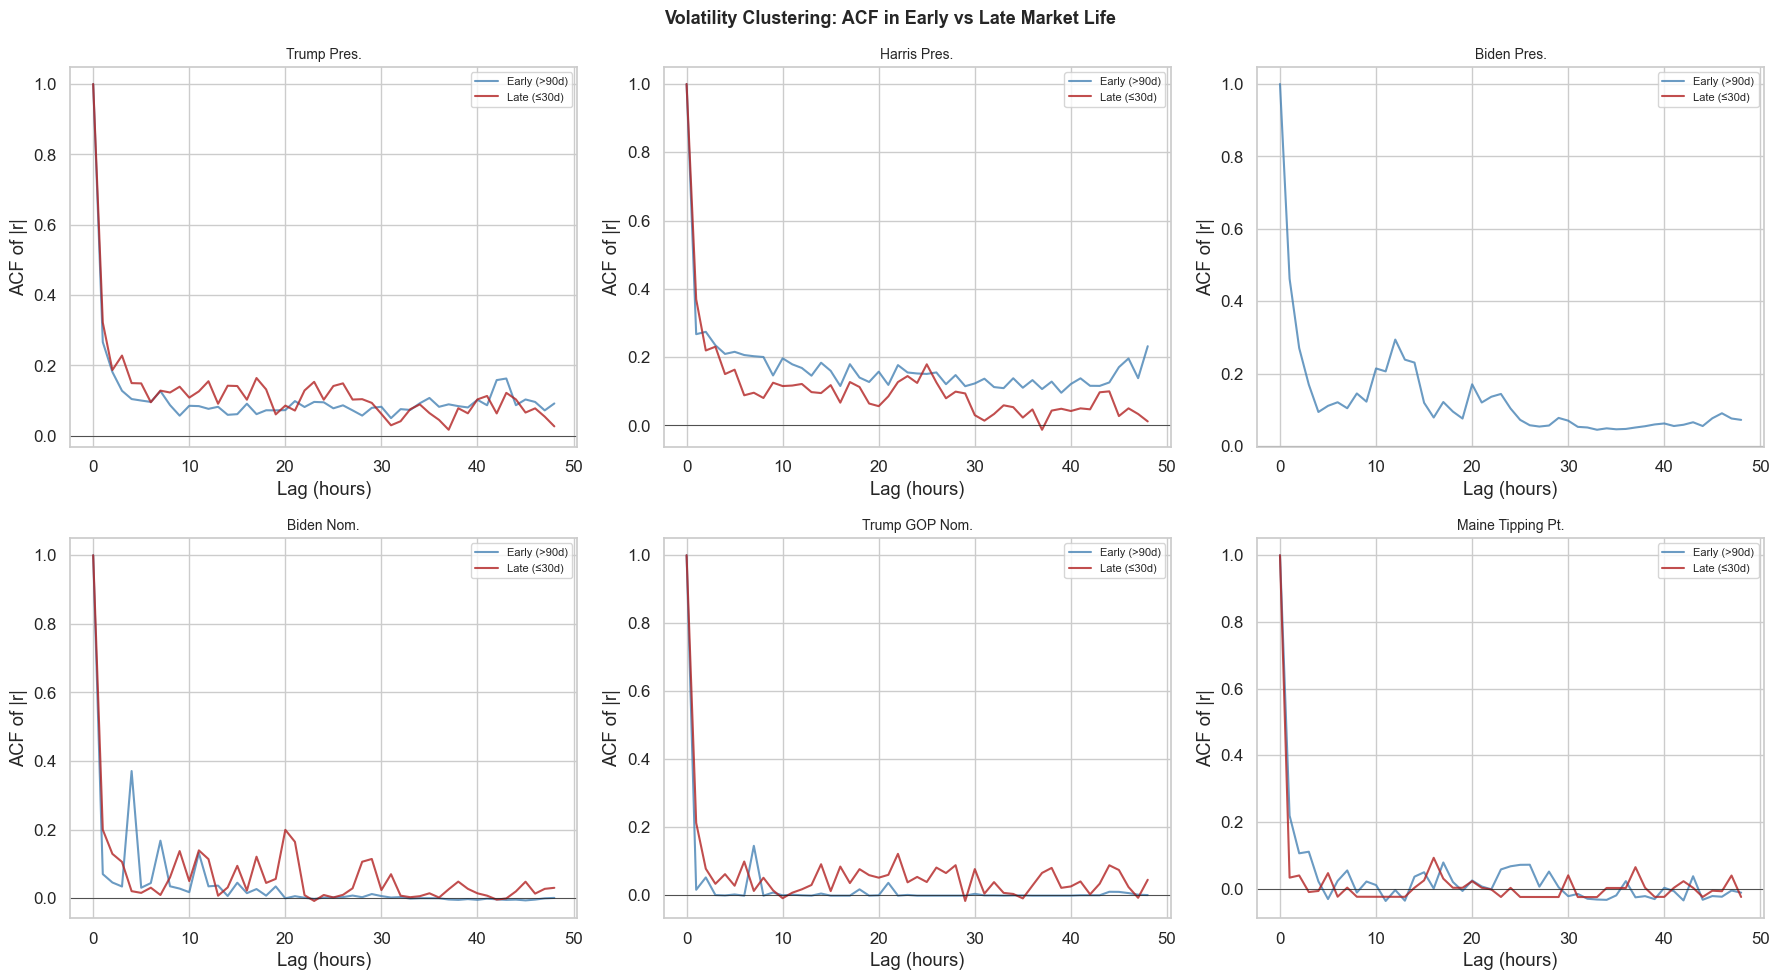

In [29]:
# ACF in early vs late market life (TTR > 90d vs TTR <= 30d)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, slug in zip(axes.flatten(), rep_slugs):
    mdf = market_dfs[slug][['abs_logit_return', 'time_to_resolution']].dropna()
    
    late = mdf[mdf['time_to_resolution'] <= 30]['abs_logit_return']
    early = mdf[mdf['time_to_resolution'] > 90]['abs_logit_return']
    
    for series, label, color in [(early, 'Early (>90d)', 'steelblue'), 
                                  (late, 'Late (≤30d)', 'firebrick')]:
        if len(series) >= NLAGS + 5:
            acf_vals = acf(series.values, nlags=NLAGS, fft=True)
            ax.plot(range(NLAGS + 1), acf_vals, label=label, color=color, alpha=0.8)
    
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_title(LABEL_MAP.get(slug, slug[:25]), fontsize=10)
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('ACF of |r|')
    ax.legend(fontsize=8)

fig.suptitle('Volatility Clustering: ACF in Early vs Late Market Life', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_acf_by_deadline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Reversal Dynamics Under Different Conditions

Do post-shock reversal patterns differ between high/low activity periods or near/far from resolution?

In [30]:
from src.analyze.reversal import conditional_returns

def reversal_by_condition(df, condition_col, split_val, label_lo='Below', label_hi='Above'):
    """Compute reversal stats split by a condition threshold."""
    clean = df[['logit_return', condition_col]].dropna()
    lo = clean[clean[condition_col] <= split_val][['logit_return']].copy()
    hi = clean[clean[condition_col] > split_val][['logit_return']].copy()
    
    results = []
    for subset, label in [(lo, label_lo), (hi, label_hi)]:
        if len(subset) < 50:
            continue
        cr = conditional_returns(subset, sigma_mult=2.0, horizons=[1, 6, 12, 24])
        cr['condition'] = label
        results.append(cr)
    
    return pd.concat(results) if results else pd.DataFrame()

# Reversal by activity level (pooled across markets with enough data)
print('=== Reversal by Activity Level (Pooled) ===')
pooled_clean = df_all[['logit_return', 'trade_rate_1h']].dropna()
median_tr = pooled_clean['trade_rate_1h'].median()

rev_activity = reversal_by_condition(
    df_all, 'trade_rate_1h', median_tr, 
    f'Low (≤{median_tr:.0f})', f'High (>{median_tr:.0f})')
if not rev_activity.empty:
    print(rev_activity.to_string(float_format='{:.4f}'.format))

=== Reversal by Activity Level (Pooled) ===
         mean_after_pos  se_after_pos  n_pos  tstat_pos  pval_pos  mean_after_neg  se_after_neg  n_neg  tstat_neg  pval_neg   condition
horizon                                                                                                                                
1               -0.0361        0.0124    495    -2.9119    0.0038          0.0221        0.0085    524     2.6036    0.0095   Low (≤16)
6               -0.0728        0.0172    495    -4.2341    0.0000          0.0375        0.0139    524     2.7029    0.0071   Low (≤16)
12              -0.0595        0.0220    495    -2.7078    0.0070          0.0353        0.0180    522     1.9587    0.0507   Low (≤16)
24              -0.0763        0.0265    495    -2.8804    0.0041          0.0268        0.0222    522     1.2100    0.2268   Low (≤16)
1               -0.0101        0.0094    394    -1.0764    0.2824         -0.0017        0.0082    407    -0.2119    0.8323  High (>16)
6   

In [31]:
# Reversal by deadline proximity (pooled)
print('=== Reversal by Deadline Proximity (Pooled) ===')
rev_deadline = reversal_by_condition(
    df_all, 'time_to_resolution', 30, 'Last 30d', 'Earlier (>30d)')
if not rev_deadline.empty:
    print(rev_deadline.to_string(float_format='{:.4f}'.format))

=== Reversal by Deadline Proximity (Pooled) ===
         mean_after_pos  se_after_pos  n_pos  tstat_pos  pval_pos  mean_after_neg  se_after_neg  n_neg  tstat_neg  pval_neg       condition
horizon                                                                                                                                    
1               -0.0997        0.0622     85    -1.6032    0.1126          0.0525        0.0321     69     1.6348    0.1067        Last 30d
6               -0.1271        0.0868     85    -1.4647    0.1467          0.0564        0.0775     69     0.7279    0.4691        Last 30d
12              -0.0827        0.0971     85    -0.8513    0.3970          0.0773        0.0878     68     0.8805    0.3817        Last 30d
24              -0.0769        0.1163     85    -0.6611    0.5104          0.0198        0.1093     68     0.1815    0.8565        Last 30d
1               -0.0237        0.0058    790    -4.0510    0.0001          0.0071        0.0059    850     1.221

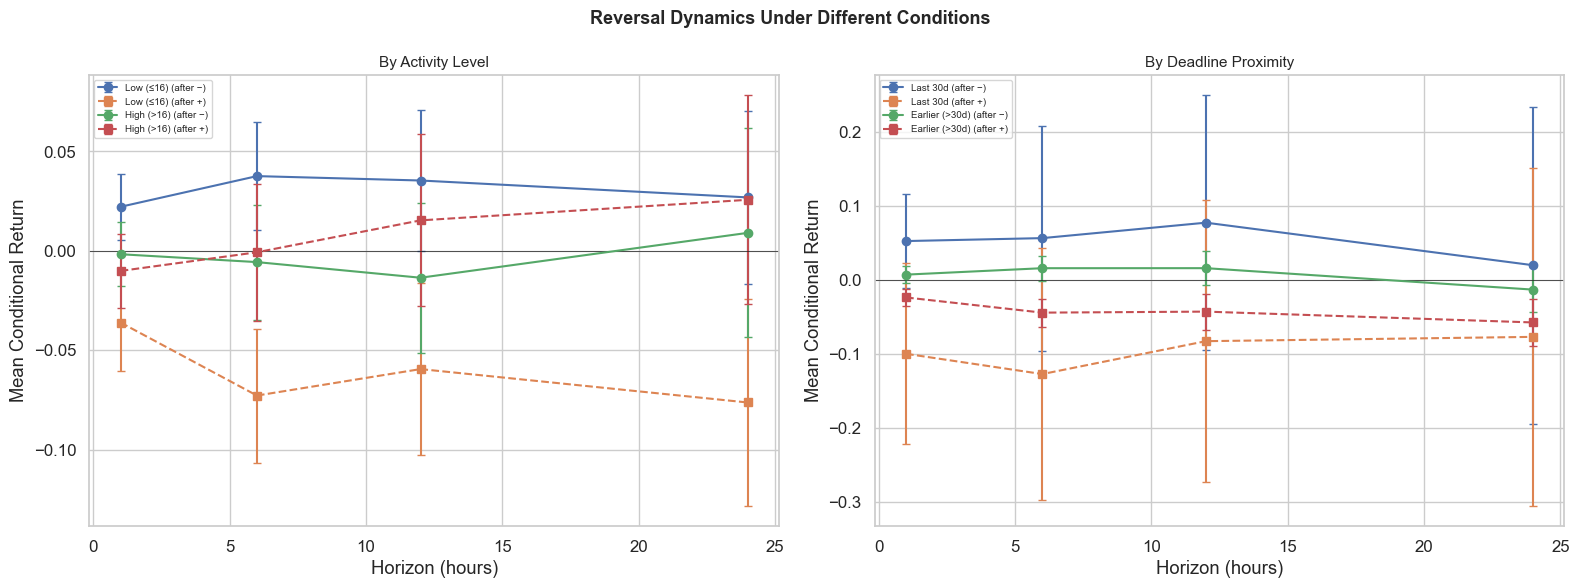

In [32]:
# Visualise reversal comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, rev_df, title in zip(axes, [rev_activity, rev_deadline],
    ['By Activity Level', 'By Deadline Proximity']):
    if rev_df.empty:
        ax.set_title(f'{title} (insufficient data)')
        continue
    
    for cond in rev_df['condition'].unique():
        subset = rev_df[rev_df['condition'] == cond]
        ax.errorbar(subset.index, subset['mean_after_neg'], 
                    yerr=1.96 * subset['se_after_neg'],
                    marker='o', capsize=3, label=f'{cond} (after −)')
        ax.errorbar(subset.index, subset['mean_after_pos'],
                    yerr=1.96 * subset['se_after_pos'],
                    marker='s', capsize=3, linestyle='--', label=f'{cond} (after +)')
    
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Horizon (hours)')
    ax.set_ylabel('Mean Conditional Return')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7)

fig.suptitle('Reversal Dynamics Under Different Conditions', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_reversal_by_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Cross-Market Variation: Volume, Duration, and Signature Strength

Are signature–condition relationships stronger in high-volume or longer-lived markets?

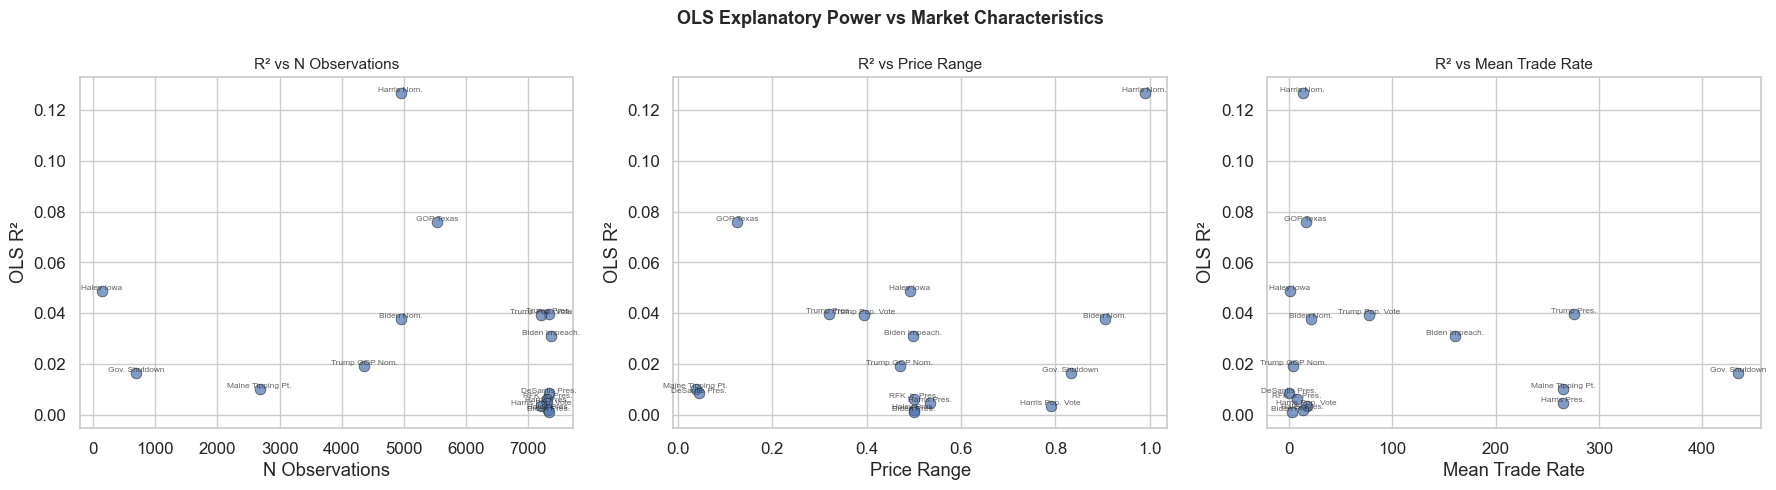

In [33]:
# Scatter: per-market R² from activity regression vs market characteristics
# Merge with overview table
df_per_mkt_ext = df_per_mkt.merge(
    overview.reset_index()[['label', 'n_obs', 'price_range', 'kurtosis', 'mean_trade_rate']],
    left_on='market', right_on='label', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, x_col, x_label in zip(axes,
    ['n_obs', 'price_range', 'mean_trade_rate'],
    ['N Observations', 'Price Range', 'Mean Trade Rate']):
    
    ax.scatter(df_per_mkt_ext[x_col], df_per_mkt_ext['R2'], 
               s=60, alpha=0.7, edgecolors='k', linewidth=0.5)
    
    for _, row in df_per_mkt_ext.iterrows():
        ax.annotate(row['market'], (row[x_col], row['R2']),
                    fontsize=6, alpha=0.7, ha='center', va='bottom')
    
    ax.set_xlabel(x_label)
    ax.set_ylabel('OLS R²')
    ax.set_title(f'R² vs {x_label}', fontsize=11)

fig.suptitle('OLS Explanatory Power vs Market Characteristics', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_r2_vs_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Comprehensive summary: how do tail heaviness, clustering, and volatility
# relate to mean activity across markets?
mkt_summary_rows = []
for slug, mdf in market_dfs.items():
    lr = mdf['logit_return'].dropna()
    alr = mdf['abs_logit_return'].dropna()
    if len(lr) < 50:
        continue
    
    try:
        lb10 = float(acorr_ljungbox(alr, lags=[10], return_df=True)['lb_pvalue'].iloc[0])
    except Exception:
        lb10 = np.nan
    
    acf1 = float(acf(alr.values, nlags=1, fft=True)[1]) if len(alr) >= 10 else np.nan
    
    mkt_summary_rows.append({
        'market': LABEL_MAP.get(slug, slug[:25]),
        'market_type': TYPE_MAP.get(slug, ''),
        'n_obs': len(lr),
        'mean_abs_r': alr.mean(),
        'kurtosis': float(sp_stats.kurtosis(lr.values)),
        'acf1_abs_r': acf1,
        'lb10_p': lb10,
        'mean_trade_rate': mdf['trade_rate_1h'].mean(),
        'mean_ttr': mdf['time_to_resolution'].mean(),
    })

df_mkt_summary = pd.DataFrame(mkt_summary_rows).sort_values('kurtosis', ascending=False)

print('=== Cross-Market Signature Summary ===')
df_mkt_summary.style.format({
    'mean_abs_r': '{:.4f}', 'kurtosis': '{:.1f}', 'acf1_abs_r': '{:.3f}',
    'lb10_p': '{:.4f}', 'mean_trade_rate': '{:.1f}', 'mean_ttr': '{:.0f}',
})

=== Cross-Market Signature Summary ===


,market,market_type,n_obs,mean_abs_r,kurtosis,acf1_abs_r,lb10_p,mean_trade_rate,mean_ttr
6,Biden Nom.,nomination,4955,0.0120,1767.4,0.254,0.0000,21.5,115
7,Biden Pres.,presidential,7332,0.0060,1661.8,0.465,0.0000,2.9,153
10,Harris Pop. Vote,popular_vote,7211,0.0094,1459.6,0.348,0.0000,17.0,150
3,Trump GOP Nom.,nomination,4366,0.0041,1401.4,0.103,0.0000,4.0,91
14,RFK Jr. Pres.,presidential,7308,0.0134,920.8,0.262,0.0000,7.7,152
5,Trump Pop. Vote,popular_vote,7212,0.0051,714.0,0.232,0.0000,77.0,150
0,Biden Impeach.,policy,7367,0.0057,377.2,0.161,0.0000,160.7,154
8,Harris Nom.,nomination,4950,0.0172,252.6,0.360,0.0000,13.1,116
15,DeSantis Pres.,presidential,7330,0.0077,238.3,0.117,0.0000,0.1,153
9,Harris Pres.,presidential,7306,0.0107,168.8,0.274,0.0000,265.0,152


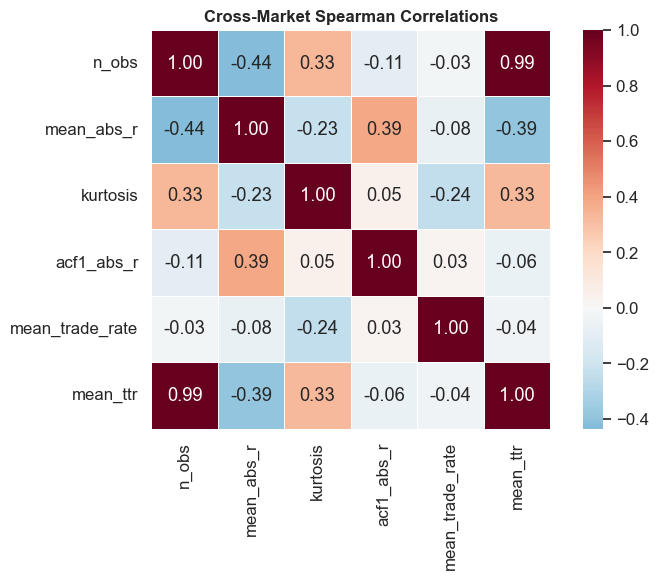

In [35]:
# Correlation matrix of cross-market features
corr_cols = ['n_obs', 'mean_abs_r', 'kurtosis', 'acf1_abs_r', 'mean_trade_rate', 'mean_ttr']
corr_matrix = df_mkt_summary[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Cross-Market Spearman Correlations', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'rq3_cross_market_corr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Summary


In [37]:
# Final synthesis: last-30d vs earlier pooled comparison
last30 = df_all[df_all['time_to_resolution'] <= 30]
earlier = df_all[df_all['time_to_resolution'] > 30]

print('=== Pooled Last 30d vs Earlier ===')
for label, subset in [('Earlier (>30d)', earlier), ('Last 30d', last30)]:
    lr = subset['logit_return'].dropna()
    alr = subset['abs_logit_return'].dropna()
    print(f'\n{label} (n={len(lr):,}):')
    print(f'  Mean |r|:    {alr.mean():.5f}')
    print(f'  Std r:       {lr.std():.5f}')
    print(f'  Kurtosis:    {sp_stats.kurtosis(lr.values):.1f}')
    print(f'  Skewness:    {sp_stats.skew(lr.values):.2f}')
    if len(alr) >= 20:
        print(f'  ACF(1) |r|:  {acf(alr.values, nlags=1, fft=True)[1]:.4f}')
    print(f'  Mean trade rate: {subset["trade_rate_1h"].mean():.1f}')

=== Pooled Last 30d vs Earlier ===

Earlier (>30d) (n=78,720):
  Mean |r|:    0.00792
  Std r:       0.04874
  Kurtosis:    1100.8
  Skewness:    -8.52
  ACF(1) |r|:  0.2663
  Mean trade rate: 78.6

Last 30d (n=10,327):
  Mean |r|:    0.01842
  Std r:       0.09641
  Kurtosis:    1021.4
  Skewness:    -11.95
  ACF(1) |r|:  0.3317
  Mean trade rate: 106.3
